# P&P Full Evaluation — LIBERO-PRO

Three-phase evaluation (baseline → uncertainty measurement → refinement) across
position-perturbation and distractor suites, followed by a detailed analysis section.

**Run order — first session:** 1 → 2 → 3 → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14

**Run order — subsequent sessions:** 1 → 2 → 3b → 4 → 5 → 6 → 7 → 8 → 9 → 10 → 11 → 12 → 13 → 14

---
## 1. GPU Check & Drive Mount
Run every session.

In [ ]:
import subprocess, torch
print(subprocess.run(
    ['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
    capture_output=True, text=True).stdout.strip())
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

from google.colab import drive
import os
drive.mount('/content/drive')

DRIVE       = '/content/drive/MyDrive'
CACHE_DIR   = f'{DRIVE}/smolvla_colab_cache'
HF_HOME     = f'{CACHE_DIR}/hf_models'
RESULTS_DIR = f'{DRIVE}/libero_pro_results'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(HF_HOME, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

os.environ['HF_HOME']               = HF_HOME
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['MUJOCO_GL']             = 'egl'

SNAPSHOT  = f'{CACHE_DIR}/site_packages.tar.gz'
PRO_CACHE = f'{CACHE_DIR}/libero_pro_files.tar.gz'

print(f'\nPackage snapshot: {"FOUND" if os.path.exists(SNAPSHOT) else "NOT FOUND — run Section 3"}')
print(f'LIBERO-PRO cache: {"FOUND" if os.path.exists(PRO_CACHE) else "NOT FOUND — run Section 5b"}')

NVIDIA L4, 23034 MiB
CUDA: True
GPU:  NVIDIA L4
VRAM: 23.7 GB
Mounted at /content/drive

Package snapshot: FOUND
LIBERO-PRO cache: FOUND


---
## 2. System Libraries
Run once per session (~2 min).

In [ ]:
%%bash
apt-get update -qq
apt-get install -y -qq \
    libosmesa6-dev libgl1-mesa-glx libglfw3 libglew-dev \
    libegl1-mesa-dev patchelf ffmpeg
mkdir -p /usr/share/glvnd/egl_vendor.d
echo '{"file_format_version":"1.0.0","ICD":{"library_path":"libEGL_nvidia.so.0"}}' \
    > /usr/share/glvnd/egl_vendor.d/10_nvidia.json
echo 'System deps done'

Selecting previously unselected package libglx-dev:amd64.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../00-libglx-dev_1.4.0-1_amd64.deb ...
Unpacking libglx-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgl-dev:amd64.
Preparing to unpack .../01-libgl-dev_1.4.0-1_amd64.deb ...
Unpacking libgl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libegl-dev:amd64.
Preparing to unpack .../02-libegl-dev_1.4.0-1_amd64.deb ...
Unpacking libegl-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libglvnd-core-dev:amd64.
Preparing to unpack .../03-libglvnd-core-dev_1.4.0-1_amd64.deb ...
Unpacking libglvnd-core-dev:amd64 (1.4.0-1) ...
Selecting previously unselected package libgles1:amd64.
Preparing to unpack .../04-libgles1_1.4.0-1_amd64.deb ...
Unpacking libgles1:amd64 (1.4.0-1) ...
Selecting previously unselected package libgles-dev:amd64.
Preparing to unpack .../05-libgles-dev_1.4.0-1_amd64.deb ...


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


---
## 3. Python Package Install & Snapshot
### 3a. Full install — FIRST SESSION ONLY
Skip to **3b** on subsequent sessions.

In [ ]:
# ── Full pip install (first session only) ────────────────────────────────────
import subprocess, os
CACHE_DIR = '/content/drive/MyDrive/smolvla_colab_cache'
SNAPSHOT  = f'{CACHE_DIR}/site_packages.tar.gz'

packages = [
    'git+https://github.com/huggingface/lerobot.git#egg=lerobot[smolvla]',
    'mujoco', 'robosuite', 'libero',
]
for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.run(['pip', 'install', '-q', pkg], check=True)

print('\nSaving snapshot to Drive...')
subprocess.run(
    ['tar', '-czf', SNAPSHOT,
     '-C', '/usr/local/lib',
     f'python3.{__import__("sys").version_info.minor}/dist-packages'],
    check=True)
print(f'Snapshot saved: {SNAPSHOT}')

### 3b. Fast restore from Drive snapshot — SUBSEQUENT SESSIONS

In [ ]:
import subprocess, sys, os, time, shutil, importlib

CACHE_DIR      = '/content/drive/MyDrive/smolvla_colab_cache'
SNAPSHOT       = f'{CACHE_DIR}/site_packages.tar.gz'
LOCAL_SNAPSHOT = '/content/site_packages_restore.tar.gz'

if not os.path.exists(SNAPSHOT):
    raise FileNotFoundError(
        'No snapshot found. Run Section 3a (full install) first to create it.'
    )

t0 = time.time()
size_mb = os.path.getsize(SNAPSHOT) / 1e6
print(f'Found snapshot on Drive: {size_mb:.0f} MB')

print('Copying snapshot from Drive to local disk (avoids Drive timeout bugs)...')
shutil.copy(SNAPSHOT, LOCAL_SNAPSHOT)

print('Extracting packages...')
result = subprocess.run(
    ['tar', '-xzf', LOCAL_SNAPSHOT, '-C', '/'],
    capture_output=True, text=True
)
os.remove(LOCAL_SNAPSHOT)

if result.returncode != 0:
    print('Restore failed:', result.stderr[:500])
else:
    elapsed = time.time() - t0
    print(f'Restored in {elapsed:.1f}s')

importlib.invalidate_caches()

for pkg in ['mujoco', 'robosuite', 'libero', 'lerobot']:
    try:
        importlib.import_module(pkg)
        print(f'  {pkg} OK')
    except ImportError as e:
        print(f'  {pkg} MISSING: {e}')
print('Restore complete.')

Found snapshot on Drive: 11198 MB
Copying snapshot from Drive to local disk (avoids Drive timeout bugs)...
Extracting packages...
Restored in 395.7s


[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /usr/local/lib/python3.12/dist-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


  mujoco OK
  robosuite OK
  libero OK
  lerobot OK
Restore complete.


---
## 4. Clone LIBERO-PRO Repo
Run every session (fast, just clones the repo without installing).

In [ ]:
import subprocess, os

REPO_DIR = '/content/LIBERO-PRO'
if not os.path.exists(REPO_DIR):
    print('Cloning LIBERO-PRO...')
    result = subprocess.run(
        ['git', 'clone', '--depth=1',
         'https://github.com/Zxy-MLlab/LIBERO-PRO.git',
         REPO_DIR],
        capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'Clone failed:\n{result.stderr}')
    print('Clone complete.')
else:
    print(f'Repo already exists at {REPO_DIR}')

# Verify bddl directory structure
bddl_root = f'{REPO_DIR}/libero/libero/bddl_files'
if os.path.exists(bddl_root):
    suites = sorted(os.listdir(bddl_root))
    print(f'LIBERO-PRO bddl suites found: {len(suites)}')
    pos_suites  = [s for s in suites if 'temp_' in s]
    with_suites = [s for s in suites if '_with_' in s]
    print(f'  Position perturbation: {pos_suites}')
    print(f'  Distractor (_with_*): {with_suites}')
else:
    print('WARNING: bddl_files not found in repo clone')

Cloning LIBERO-PRO...
Clone complete.
LIBERO-PRO bddl suites found: 52
  Position perturbation: ['libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_x0.3', 'libero_object_temp_x0.4', 'libero_object_temp_x0.5', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_object_temp_y0.3', 'libero_object_temp_y0.4', 'libero_object_temp_y0.5']
  Distractor (_with_*): ['libero_10_with_blue_stick', 'libero_10_with_diffpos_stick', 'libero_10_with_milk', 'libero_10_with_mug', 'libero_10_with_red_box', 'libero_10_with_red_stick', 'libero_goal_with_blue_stick', 'libero_goal_with_diffpos_stick', 'libero_goal_with_green_mug', 'libero_goal_with_milk', 'libero_goal_with_mug', 'libero_goal_with_red_box', 'libero_goal_with_red_stick', 'libero_goal_with_rotated_stick', 'libero_goal_with_yellow_book', 'libero_object_with_blue_stick', 'libero_object_with_diffpos_stick', 'libero_object_with_mug', 'libero_object_with_red_box', 'libero_object_with_red_stick', 'libero_object_with_tri

---
## 5. LIBERO-PRO Assets (bddl + init files)
### 5a. Download from HuggingFace & save to Drive cache — FIRST SESSION ONLY

In [ ]:
# ── Download LIBERO-PRO bddl + init files from HuggingFace and cache ─────────
# Repo: zhouxueyang/LIBERO-Pro (dataset) — contains bddl_files/ and init_files/
import sys, os, tarfile, time
from huggingface_hub import snapshot_download

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
CACHE_DIR   = '/content/drive/MyDrive/smolvla_colab_cache'
PRO_CACHE   = f'{CACHE_DIR}/libero_pro_files.tar.gz'
HF_TMP      = '/content/libero_pro_hf'

if os.path.exists(PRO_CACHE):
    print(f'Cache already exists ({os.path.getsize(PRO_CACHE)//1024//1024} MB). '
          f'Use Section 5b to restore.')
else:
    print('Downloading from HuggingFace (zhouxueyang/LIBERO-Pro)...')
    t0 = time.time()
    snapshot_download(
        repo_id='zhouxueyang/LIBERO-Pro',
        repo_type='dataset',
        local_dir=HF_TMP,
    )
    print(f'Downloaded in {time.time()-t0:.0f}s. Compressing to Drive...')

    t1 = time.time()
    with tarfile.open(PRO_CACHE, 'w:gz') as tar:
        for subdir in ['bddl_files', 'init_files']:
            src = os.path.join(HF_TMP, subdir)
            if os.path.exists(src):
                tar.add(src, arcname=subdir)
                print(f'  Packed {subdir}/')
            else:
                print(f'  WARNING: {subdir} not found in download')
    print(f'Saved to Drive in {time.time()-t1:.0f}s '
          f'({os.path.getsize(PRO_CACHE)//1024//1024} MB)')

Cache already exists (0 MB). Use Section 5b to restore.


### 5b. Restore from Drive cache — SUBSEQUENT SESSIONS

In [ ]:
# ── Restore bddl + init files from Drive cache ────────────────────────────────
import sys, os, tarfile

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
CACHE_DIR   = '/content/drive/MyDrive/smolvla_colab_cache'
PRO_CACHE   = f'{CACHE_DIR}/libero_pro_files.tar.gz'

assert os.path.exists(PRO_CACHE), f'Cache not found: {PRO_CACHE} — run Section 5a first'
print('Restoring LIBERO-PRO files from Drive cache...')
with tarfile.open(PRO_CACHE, 'r:gz') as tar:
    tar.extractall(LIBERO_SITE)
print('Restore complete.')
print(f'  bddl_files: {len(os.listdir(os.path.join(LIBERO_SITE, "bddl_files")))} entries')
print(f'  init_files: {len(os.listdir(os.path.join(LIBERO_SITE, "init_files")))} entries')

Restoring LIBERO-PRO files from Drive cache...
Restore complete.
  bddl_files: 21 entries
  init_files: 21 entries


/tmp/ipykernel_14838/1189253.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(LIBERO_SITE)


In [ ]:
# ── Pre-import libero benchmark using pip version before patching ─────────────
# Must happen before Section 6 copies LIBERO-PRO files over the pip versions.
# Python will cache this import; the patched files take effect only after
# the explicit reload in Section 10.
import libero.libero.benchmark as _bm_preload
print('libero.libero.benchmark pre-loaded (pip version cached).')

Do you want to specify a custom path for the dataset folder? (Y/N): N
Initializing the default config file...
The following information is stored in the config file: /root/.libero/config.yaml
benchmark_root: /usr/local/lib/python3.12/dist-packages/libero/libero
bddl_files: /usr/local/lib/python3.12/dist-packages/libero/libero/./bddl_files
init_states: /usr/local/lib/python3.12/dist-packages/libero/libero/./init_files
datasets: /usr/local/lib/python3.12/dist-packages/libero/libero/../datasets
assets: /usr/local/lib/python3.12/dist-packages/libero/libero/./assets
libero.libero.benchmark pre-loaded (pip version cached).


---
## 6. Merge LIBERO-PRO Files & Apply All Patches
Run every session. Copies bddl/init files from the repo, registers new suites, and applies
all compatibility patches (dynamo, torch.load, CUSTOM_KEY, object aliases, benchmark dict).

In [ ]:
import shutil, os, sys, re, importlib

LIBERO_SITE    = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
LIBERO_PRO_DIR = '/content/LIBERO-PRO'

# ── Step 1: Copy patched files from LIBERO-PRO repo ──────────────────────────
files_to_patch = [
    'benchmark/__init__.py',
    'benchmark/libero_suite_task_map.py',
    'envs/objects/__init__.py',
]
for rel_path in files_to_patch:
    src = os.path.join(LIBERO_PRO_DIR, 'libero/libero', rel_path)
    dst = os.path.join(LIBERO_SITE, rel_path)
    if not os.path.exists(src):
        print(f'WARNING: not found in clone: {rel_path}')
        continue
    os.makedirs(os.path.dirname(dst), exist_ok=True)  # create benchmark/ if missing
    bak = dst + '.original_bak'
    if os.path.exists(dst) and not os.path.exists(bak):
        shutil.copy2(dst, bak)
    shutil.copy2(src, dst)
    print(f'Patched: {rel_path}')

# Copy any new object definition .py files LIBERO-PRO added
src_objects = os.path.join(LIBERO_PRO_DIR, 'libero/libero/envs/objects')
dst_objects = os.path.join(LIBERO_SITE, 'envs/objects')
for fname in os.listdir(src_objects):
    if not fname.endswith('.py'):
        continue
    dst_file = os.path.join(dst_objects, fname)
    src_file = os.path.join(src_objects, fname)
    if not os.path.exists(dst_file):
        shutil.copy2(src_file, dst_file)
        print(f'Added new object file: {fname}')

# ── Step 2: Fix libero_mine KeyError (.get() patch) ──────────────────────────
benchmark_init = os.path.join(LIBERO_SITE, 'benchmark/__init__.py')
with open(benchmark_init, 'r') as f:
    content = f.read()
old = 'for task in libero_task_map[libero_suite]:'
new = 'for task in libero_task_map.get(libero_suite, []):'
if old in content:
    content = content.replace(old, new)
    with open(benchmark_init, 'w') as f:
        f.write(content)
    print('Fixed: .get() patch applied')
elif new in content:
    print('Already fixed: .get() patch')
else:
    print('WARNING: expected line not found in benchmark/__init__.py')

# ── Step 3: Make libero_suites dynamic ───────────────────────────────────────
with open(benchmark_init, 'r') as f:
    content = f.read()
if 'libero_suites = list(libero_task_map.keys())' in content:
    print('Already patched: libero_suites dynamic')
else:
    match = re.search(r'libero_suites\s*=\s*[\[\(].*?[\]\)]', content, re.DOTALL)
    if match:
        content = content[:match.start()] + \
                  'libero_suites = list(libero_task_map.keys())' + \
                  content[match.end():]
        with open(benchmark_init, 'w') as f:
            f.write(content)
        print('Patched: libero_suites now dynamic')
    else:
        loop_match = re.search(r'for libero_suite in libero_suites:', content)
        if loop_match:
            insert_pos = loop_match.start()
            content = content[:insert_pos] + \
                      'libero_suites = list(libero_task_map.keys())\n' + \
                      content[insert_pos:]
            with open(benchmark_init, 'w') as f:
                f.write(content)
            print('Patched: libero_suites dynamic (fallback method)')
        else:
            print('ERROR: could not find patch point — check benchmark/__init__.py manually')

# ── Step 4: Add PRO suite entries to task map from bddl dirs ─────────────────
task_map_file = os.path.join(LIBERO_SITE, 'benchmark/libero_suite_task_map.py')
PRO_SUFFIXES  = ('_lan', '_swap', '_object', '_task', '_env', '_temp')
BDDL_DIR      = os.path.join(LIBERO_SITE, 'bddl_files')

with open(task_map_file, 'r') as f:
    existing = f.read()

additions = []
for suite_dir in sorted(os.listdir(BDDL_DIR)):
    if not any(suite_dir.endswith(sfx) for sfx in PRO_SUFFIXES):
        continue
    bddl_suite_dir = os.path.join(BDDL_DIR, suite_dir)
    tasks = sorted([f.replace('.bddl', '') for f in os.listdir(bddl_suite_dir)
                    if f.endswith('.bddl')])
    if not tasks:
        continue
    has_tasks = bool(re.search(
        rf'"{re.escape(suite_dir)}"\s*[:\]]\s*\[.*?\S.*?\]',
        existing, re.DOTALL))
    if has_tasks:
        continue
    additions.append((suite_dir, tasks))

if additions:
    with open(task_map_file, 'a') as f:
        f.write('\n\n# ── LIBERO-PRO standard suites (built from bddl files) ──\n')
        for suite_name, tasks in additions:
            f.write(f'libero_task_map["{suite_name}"] = [\n')
            for task in tasks:
                f.write(f'    "{task}",\n')
            f.write(']\n\n')
    print(f'Added {len(additions)} PRO suite(s) to task map')
else:
    print('Task map: all PRO suites already registered')

# ── Step 5: Register position perturbation suites in task map ────────────────
TEMP_TASKS = [
    'pick_up_the_alphabet_soup_and_place_it_in_the_basket',
    'pick_up_the_bbq_sauce_and_place_it_in_the_basket',
    'pick_up_the_butter_and_place_it_in_the_basket',
    'pick_up_the_chocolate_pudding_and_place_it_in_the_basket',
    'pick_up_the_cream_cheese_and_place_it_in_the_basket',
    'pick_up_the_ketchup_and_place_it_in_the_basket',
    'pick_up_the_milk_and_place_it_in_the_basket',
    'pick_up_the_orange_juice_and_place_it_in_the_basket',
    'pick_up_the_salad_dressing_and_place_it_in_the_basket',
    'pick_up_the_tomato_sauce_and_place_it_in_the_basket',
]
TEMP_STRENGTHS = (
    [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] +
    [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]
)
with open(task_map_file, 'r') as f:
    existing = f.read()
temp_additions = [s for s in TEMP_STRENGTHS if f'"{s}"' not in existing]
if temp_additions:
    with open(task_map_file, 'a') as f:
        f.write('\n\n# ── Position perturbation suites ──\n')
        for suite in temp_additions:
            f.write(f'libero_task_map["{suite}"] = [\n')
            for t in TEMP_TASKS:
                f.write(f'    "{t}",\n')
            f.write(']\n')
    print(f'Added {len(temp_additions)} position perturbation suites')
else:
    print('Position perturbation suites already registered')

# ── Step 6: Copy custom assets for _with_milk suites ─────────────────────────
REPO_ASSETS = f'{LIBERO_PRO_DIR}/notebooks/custom_assets'
DIST_ASSETS = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/notebooks/custom_assets'
if os.path.exists(REPO_ASSETS) and not os.path.exists(DIST_ASSETS):
    shutil.copytree(REPO_ASSETS, DIST_ASSETS)
    print('Copied custom_assets to dist-packages')


print('\nSection 6 complete. Run torch patches + policy load next, then Section 10 will reload benchmark.')

Patched: benchmark/__init__.py
Patched: benchmark/libero_suite_task_map.py
Patched: envs/objects/__init__.py
Added new object file: self_designed_object.py
Fixed: .get() patch applied
Patched: libero_suites now dynamic
Task map: all PRO suites already registered
Added 10 position perturbation suites
Copied custom_assets to dist-packages

Section 6 complete. Run torch patches + policy load next, then Section 10 will reload benchmark.


---
## 9. Load Policy (pi0.5)
Run every session.

In [ ]:
# # Torch Patches

# import torch
# import torch.ao.quantization as _taoq

# # Fix CUSTOM_KEY ImportError
# if not hasattr(_taoq, 'CUSTOM_KEY'):
#     setattr(_taoq, 'CUSTOM_KEY', 'custom')

# # Fix torch.load weights_only default (PyTorch 2.6)
# if not hasattr(torch, '_libero_true_load'):
#     torch._libero_true_load = torch.load
# _orig_load = torch._libero_true_load
# def _patched_load(*args, **kwargs):
#     kwargs.setdefault('weights_only', False)
#     return _orig_load(*args, **kwargs)
# torch.load = _patched_load

# # Disable torch dynamo (guard API mismatch)
# torch._dynamo.config.disable = True

# import importlib
# importlib.invalidate_caches()

# print('Torch patches applied.')

Torch patches applied.


In [ ]:
# import time, json, torch, numpy as np, os, math
# from transformers import AutoTokenizer
# from lerobot.policies.pi05.modeling_pi05 import PI05Policy
# from libero.libero import benchmark, get_libero_path
# from libero.libero.envs import OffScreenRenderEnv
# from lerobot.policies.factory import make_pre_post_processors

# from huggingface_hub import login
# login()   # paste HF token; accept PaliGemma license at hf.co/google/paligemma-3b-pt-224

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# policy = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned').to(device).eval()
# tokenizer = AutoTokenizer.from_pretrained('google/paligemma-3b-pt-224')
# print(f'PI05 loaded — {sum(p.numel() for p in policy.parameters())/1e6:.0f}M params on {device}')

# CAMERAS             = ['agentview', 'robot0_eye_in_hand']
# IMG_SIZE            = 360
# LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
# NUM_STEPS_WAIT      = 10

# preprocess, postprocess = make_pre_post_processors(
#     policy.config,
#     'lerobot/pi05_libero_finetuned',
#     preprocessor_overrides={'device_processor': {'device': str(device)}},
# )

# def _quat2axisangle(quat):
#     if quat[3] > 1.0:  quat[3] = 1.0
#     elif quat[3] < -1.0: quat[3] = -1.0
#     den = np.sqrt(1.0 - quat[3] ** 2)
#     if math.isclose(den, 0.0): return np.zeros(3)
#     return (quat[:3] * 2.0 * math.acos(quat[3])) / den

# def obs_to_policy(obs_dict, task_desc, device):
#     agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
#     wrist      = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])
#     img_agent  = torch.from_numpy(agentview / 255.0).permute(2,0,1).float()
#     img_wrist  = torch.from_numpy(wrist     / 255.0).permute(2,0,1).float()
#     state = np.concatenate([
#         obs_dict['robot0_eef_pos'],
#         _quat2axisangle(obs_dict['robot0_eef_quat']),
#         obs_dict['robot0_gripper_qpos'],
#     ])
#     return {
#         'observation.images.image':  img_agent,
#         'observation.images.image2': img_wrist,
#         'observation.state': torch.from_numpy(state).float(),
#         'task': task_desc,
#     }

# def run_episode(env, init_state, policy, task_desc, max_steps, device):
#     env.reset(); policy.reset()
#     obs = env.set_init_state(init_state)
#     for _ in range(NUM_STEPS_WAIT):
#         obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
#     t0 = time.time()
#     for step in range(max_steps):
#         raw_obs = obs_to_policy(obs, task_desc, device)
#         batch   = preprocess(raw_obs)
#         with torch.no_grad():
#             action = policy.select_action(batch)
#         action = postprocess(action)
#         if isinstance(action, torch.Tensor):
#             action = action.squeeze(0).cpu().numpy()
#         obs, _, done, _ = env.step(action)
#         if env.check_success():
#             return True, step+1, time.time()-t0
#         if done:
#             break
#     return False, step+1, time.time()-t0

# print('Eval helpers defined.')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


ImportError: cannot import name 'NUMERIC_DEBUG_HANDLE_KEY' from 'torch.ao.quantization' (/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/__init__.py)

In [ ]:
import os, torch, numpy as np, time, json, math
from transformers import AutoTokenizer

# ── 1. Globally disable torch.dynamo ─────────────────────────────────────────
os.environ['TORCHDYNAMO_DISABLE'] = '1'
import torch._dynamo
torch._dynamo.config.disable = True
print('torch.dynamo disabled globally.')

# ── 2. Restore any previous torch.load patch ─────────────────────────────────
if hasattr(torch, '_libero_true_load'):
    torch.load = torch._libero_true_load

# ── 3. Patch torch.ao.quantization constants ─────────────────────────────────
import torch.ao.quantization as _taoq
for name, val in [('CUSTOM_KEY', 'custom'),
                  ('NUMERIC_DEBUG_HANDLE_KEY', 'numeric_debug_handle')]:
    if not hasattr(_taoq, name):
        setattr(_taoq, name, val)
        print(f'Patched torch.ao.quantization.{name}')

# ── 4. Fix torch.load for LIBERO .pruned_init files ──────────────────────────
try:
    torch.serialization.add_safe_globals([
        np.core.multiarray._reconstruct,
        np.ndarray, np.dtype,
        np.core.multiarray.scalar,
    ])
except Exception:
    pass

if not hasattr(torch, '_libero_true_load'):
    torch._libero_true_load = torch.load
_true = torch._libero_true_load

def _patched_load(*args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _true(*args, **kwargs)

torch.load = _patched_load
print('torch.load patched (weights_only=False default).')

# ── 5. Load policy ────────────────────────────────────────────────────────────
from lerobot.policies.pi05.modeling_pi05 import PI05Policy
from libero.libero import benchmark, get_libero_path
from libero.libero.envs import OffScreenRenderEnv
from lerobot.policies.factory import make_pre_post_processors
from huggingface_hub import login

login()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

policy = PI05Policy.from_pretrained('lerobot/pi05_libero_finetuned').to(device).eval()
tokenizer = AutoTokenizer.from_pretrained('google/paligemma-3b-pt-224')
print(f'PI05 loaded — {sum(p.numel() for p in policy.parameters())/1e6:.0f}M params on {device}')

CAMERAS             = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE            = 360
LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
NUM_STEPS_WAIT      = 10

preprocess, postprocess = make_pre_post_processors(
    policy.config,
    'lerobot/pi05_libero_finetuned',
    preprocessor_overrides={'device_processor': {'device': str(device)}},
)

def _quat2axisangle(quat):
    if quat[3] > 1.0:  quat[3] = 1.0
    elif quat[3] < -1.0: quat[3] = -1.0
    den = np.sqrt(1.0 - quat[3] ** 2)
    if math.isclose(den, 0.0): return np.zeros(3)
    return (quat[:3] * 2.0 * math.acos(quat[3])) / den

def obs_to_policy(obs_dict, task_desc, device):
    agentview = np.ascontiguousarray(obs_dict['agentview_image'][::-1, ::-1])
    wrist      = np.ascontiguousarray(obs_dict['robot0_eye_in_hand_image'][::-1, ::-1])
    img_agent  = torch.from_numpy(agentview / 255.0).permute(2,0,1).float()
    img_wrist  = torch.from_numpy(wrist     / 255.0).permute(2,0,1).float()
    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])
    return {
        'observation.images.image':  img_agent,
        'observation.images.image2': img_wrist,
        'observation.state': torch.from_numpy(state).float(),
        'task': task_desc,
    }

def run_episode(env, init_state, policy, task_desc, max_steps, device):
    env.reset(); policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
    t0 = time.time()
    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch   = preprocess(raw_obs)
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)
        if isinstance(action, torch.Tensor):
            action = action.squeeze(0).cpu().numpy()
        obs, _, done, _ = env.step(action)
        if env.check_success():
            return True, step+1, time.time()-t0
        if done:
            break
    return False, step+1, time.time()-t0

print('Eval helpers defined.')

torch.dynamo disabled globally.
torch.load patched (weights_only=False default).
The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi
Loading model from: lerobot/pi05_libero_finetuned


✓ Loaded state dict from model.safetensors
All keys loaded successfully!
PI05 loaded — 4143M params on cuda
Eval helpers defined.


---
## 7. Generate Init States for Position Perturbation Suites
Must run once per session (or once ever if you cache results to Drive).
Regenerates `.pruned_init` files using the perturbed bddl positions.

In [ ]:
import shutil, os, sys

import numpy as np, random
np.random.seed(42)
random.seed(42)

LIBERO_SITE  = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
BDDL_DST     = os.path.join(LIBERO_SITE, 'bddl_files')
INIT_DST     = os.path.join(LIBERO_SITE, 'init_files')
REPO_BDDL    = '/content/LIBERO-PRO/libero/libero/bddl_files'
LIBERO_OBJ_INIT = os.path.join(INIT_DST, 'libero_object')

STRENGTHS = [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] + \
            [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]

for suite in STRENGTHS:
    src_bddl = os.path.join(REPO_BDDL, suite)
    dst_bddl = os.path.join(BDDL_DST, suite)
    dst_init = os.path.join(INIT_DST, suite)

    if not os.path.exists(src_bddl):
        print(f'  SKIP (not in repo): {suite}')
        continue

    # Copy bddl files
    if not os.path.exists(dst_bddl):
        shutil.copytree(src_bddl, dst_bddl)
        print(f'  Copied bddl: {suite}')
    else:
        print(f'  bddl already exists: {suite}')

    # Copy init files from libero_object (same tasks, same robot start state)
    if not os.path.exists(dst_init):
        shutil.copytree(LIBERO_OBJ_INIT, dst_init)
        print(f'  Copied init files from libero_object → {suite}')
    else:
        print(f'  init already exists: {suite}')

print('\nDone.')

  Copied bddl: libero_object_temp_x0.1
  Copied init files from libero_object → libero_object_temp_x0.1
  Copied bddl: libero_object_temp_x0.2
  Copied init files from libero_object → libero_object_temp_x0.2
  Copied bddl: libero_object_temp_x0.3
  Copied init files from libero_object → libero_object_temp_x0.3
  Copied bddl: libero_object_temp_x0.4
  Copied init files from libero_object → libero_object_temp_x0.4
  Copied bddl: libero_object_temp_x0.5
  Copied init files from libero_object → libero_object_temp_x0.5
  Copied bddl: libero_object_temp_y0.1
  Copied init files from libero_object → libero_object_temp_y0.1
  Copied bddl: libero_object_temp_y0.2
  Copied init files from libero_object → libero_object_temp_y0.2
  Copied bddl: libero_object_temp_y0.3
  Copied init files from libero_object → libero_object_temp_y0.3
  Copied bddl: libero_object_temp_y0.4
  Copied init files from libero_object → libero_object_temp_y0.4
  Copied bddl: libero_object_temp_y0.5
  Copied init files from 

In [ ]:
import numpy as np, torch, os, sys
from libero.libero.envs import OffScreenRenderEnv

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
CAMERAS     = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE    = 360
N_STATES    = 10

TARGET_TEMP_SUITES = [
    'libero_object_temp_x0.1',
    'libero_object_temp_y0.1',
    'libero_object_temp_y0.2',
    'libero_object_temp_x0.2',
]

TASKS = [
    'pick_up_the_alphabet_soup_and_place_it_in_the_basket',
    'pick_up_the_bbq_sauce_and_place_it_in_the_basket',
    'pick_up_the_butter_and_place_it_in_the_basket',
    'pick_up_the_chocolate_pudding_and_place_it_in_the_basket',
    'pick_up_the_cream_cheese_and_place_it_in_the_basket',
    'pick_up_the_ketchup_and_place_it_in_the_basket',
    'pick_up_the_milk_and_place_it_in_the_basket',
    'pick_up_the_orange_juice_and_place_it_in_the_basket',
    'pick_up_the_salad_dressing_and_place_it_in_the_basket',
    'pick_up_the_tomato_sauce_and_place_it_in_the_basket',
]

for suite in TARGET_TEMP_SUITES:
    save_dir = os.path.join(LIBERO_SITE, 'init_files', suite)
    os.makedirs(save_dir, exist_ok=True)
    print(f'\nGenerating init states for {suite}...')

    for task in TASKS:
        bddl_path = os.path.join(LIBERO_SITE, 'bddl_files', suite, task + '.bddl')
        save_path = os.path.join(save_dir, task + '.pruned_init')

        # Force overwrite — delete any existing placeholder
        if os.path.exists(save_path):
            os.remove(save_path)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_path,
            camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )
        states = []
        for _ in range(N_STATES):
            env.reset()
            states.append(env.sim.get_state().flatten())
        env.close()

        states_arr = np.array(states)
        torch.save(states_arr, save_path)
        print(f'  {task}: shape={states_arr.shape}')

print('\nDone.')


Generating init states for libero_object_temp_x0.1...
Local assets not found. Downloading from HuggingFace Hub...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 586 files:   0%|          | 0/586 [00:00<?, ?it/s]

Assets downloaded successfully to /root/.cache/libero/assets
  pick_up_the_alphabet_soup_and_place_it_in_the_basket: shape=(10, 110)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  pick_up_the_bbq_sauce_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_butter_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_chocolate_pudding_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_cream_cheese_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_ketchup_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_milk_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_orange_juice_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_salad_dressing_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_tomato_sauce_and_place_it_in_the_basket: shape=(10, 110)

Generating init states for libero_object_temp_y0.1...
  pick_up_the_alphabet_soup_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_bbq_sauce_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_butter_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_chocolate_pudding_and_place_it_in_the_basket: shape=(10, 110)
  pick_up_the_cream_cheese_and_place_it_

---
## 8. Generate Init States for Distractor Suites
Run once (idempotent — skips tasks already done).

In [ ]:
import shutil, os, sys, importlib
import numpy as np, torch
from libero.libero.envs import OffScreenRenderEnv

LIBERO_SITE   = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
REPO_BDDL     = '/content/LIBERO-PRO/libero/libero/bddl_files'
task_map_file = os.path.join(LIBERO_SITE, 'benchmark/libero_suite_task_map.py')
BDDL_DIR      = os.path.join(LIBERO_SITE, 'bddl_files')
CAMERAS       = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE      = 360
N_STATES      = 10

WITH_SUITES = [
    'libero_spatial_with_milk',
    # 'libero_spatial_with_yellow_book',
    # 'libero_goal_with_milk',
    'libero_goal_with_yellow_book',
    # 'libero_object_with_yellow_book',
    # 'libero_10_with_milk',
]

# ── Step 1: Copy bddl files from repo ────────────────────────────────────────
for suite in WITH_SUITES:
    src = os.path.join(REPO_BDDL, suite)
    dst = os.path.join(BDDL_DIR, suite)
    if not os.path.exists(src):
        print(f'  SKIP (not in repo): {suite}')
        continue
    if not os.path.exists(dst):
        shutil.copytree(src, dst)
        print(f'  Copied bddl: {suite}')
    else:
        print(f'  bddl already exists: {suite}')

# ── Step 2: Generate init states ─────────────────────────────────────────────
for suite in WITH_SUITES:
    bddl_dir = os.path.join(BDDL_DIR, suite)
    save_dir = os.path.join(LIBERO_SITE, 'init_files', suite)
    if not os.path.exists(bddl_dir):
        print(f'  SKIP (no bddl dir): {suite}')
        continue
    os.makedirs(save_dir, exist_ok=True)
    tasks = sorted([f.replace('.bddl','') for f in os.listdir(bddl_dir) if f.endswith('.bddl')])
    print(f'\nGenerating init states for {suite} ({len(tasks)} tasks)...')
    for task in tasks:
        bddl_path = os.path.join(bddl_dir, task + '.bddl')
        save_path = os.path.join(save_dir, task + '.pruned_init')
        if os.path.exists(save_path):
            print(f'  SKIP (exists): {task[:55]}')
            continue
        try:
            env = OffScreenRenderEnv(
                bddl_file_name=bddl_path,
                camera_names=CAMERAS,
                camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
                has_offscreen_renderer=True, use_camera_obs=True,
                has_renderer=False, reward_shaping=False,
            )
            states = []
            for _ in range(N_STATES):
                env.reset()
                states.append(env.sim.get_state().flatten())
            env.close()
            states_arr = np.array(states)
            torch.save(states_arr, save_path)
            print(f'  {task[:55]}: {states_arr.shape}')
        except Exception as e:
            print(f'  ERROR {task[:45]}: {e}')

# ── Step 3: Register in task map file ────────────────────────────────────────
with open(task_map_file, 'r') as f:
    existing = f.read()

added = []
with open(task_map_file, 'a') as f:
    f.write('\n\n# ── _with_* suites ──\n')
    for suite in WITH_SUITES:
        if f'"{suite}"' in existing:
            print(f'  {suite}: already in task map')
            continue
        bddl_suite_dir = os.path.join(BDDL_DIR, suite)
        if not os.path.exists(bddl_suite_dir):
            continue
        tasks = sorted([t.replace('.bddl','') for t in os.listdir(bddl_suite_dir)
                        if t.endswith('.bddl')])
        f.write(f'libero_task_map["{suite}"] = [\n')
        for t in tasks:
            f.write(f'    "{t}",\n')
        f.write(']\n\n')
        added.append(suite)
        print(f'  Added to task map: {suite} ({len(tasks)} tasks)')

# ── Step 4: Reload task map and inject into benchmark.task_maps ──────────────
import libero.libero.benchmark.libero_suite_task_map as _tm
importlib.reload(_tm)
import libero.libero.benchmark as _bm_with
importlib.reload(_bm_with)

from libero.libero.benchmark.libero_suite_task_map import libero_task_map
from libero.libero.benchmark import grab_language_from_filename, Task

for suite in WITH_SUITES:
    if suite not in _bm_with.task_maps and suite in libero_task_map:
        _bm_with.task_maps[suite] = {}
        for task_name in libero_task_map[suite]:
            try:
                language = grab_language_from_filename(task_name + '.bddl')
                _bm_with.task_maps[suite][task_name] = Task(
                    name=task_name, language=language,
                    problem_folder=suite, bddl_file=task_name + '.bddl')
            except Exception as e:
                print(f'    WARNING task {task_name}: {e}')
        print(f'  Injected {len(_bm_with.task_maps[suite])} tasks into task_maps[{suite}]')

# ── Step 5: Extend monkey-patch to cover both temp and _with_* suites ─────────
TEMP_STRENGTHS = (
    [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] +
    [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]
)
ALL_CUSTOM_SUITES = TEMP_STRENGTHS + WITH_SUITES

_orig = _bm_with.get_benchmark_dict

def _patched_get_benchmark_dict():
    result = dict(_orig())
    for suite in ALL_CUSTOM_SUITES:
        if suite not in result and \
           suite in _bm_with.task_maps and \
           _bm_with.task_maps[suite]:
            def make_cls(s):
                class _Suite:
                    def __init__(self):
                        self._tasks = list(_bm_with.task_maps[s].values())
                        self.n_tasks = len(self._tasks)
                    def get_task(self, i): return self._tasks[i]
                    def get_task_names(self): return list(_bm_with.task_maps[s].keys())
                    def get_task_init_states(self, i):
                        import torch, os
                        task = self._tasks[i]
                        init_file = os.path.join(
                            f'/usr/local/lib/python3.{sys.version_info.minor}'
                            f'/dist-packages/libero/libero/init_files',
                            task.problem_folder,
                            task.bddl_file.replace('.bddl', '.pruned_init'))
                        return torch.load(init_file)
                return _Suite
            result[suite] = make_cls(suite)
    return result

_bm_with.get_benchmark_dict = _patched_get_benchmark_dict

# ── Verify ────────────────────────────────────────────────────────────────────
bm = _bm_with.get_benchmark_dict()
for suite in WITH_SUITES:
    if suite in bm:
        n = bm[suite]().n_tasks
        MAX_STEPS_MAP[suite] = 300
        print(f'  {suite}: {n} tasks ✓')
    else:
        print(f'  {suite}: NOT in benchmark_dict ✗')

  bddl already exists: libero_spatial_with_milk
  bddl already exists: libero_goal_with_yellow_book

Generating init states for libero_spatial_with_milk (10 tasks)...
  SKIP (exists): FLOOR_SCENE1_pick_the_akita_black_bowl_between_the_plat
  SKIP (exists): FLOOR_SCENE1_pick_the_akita_black_bowl_from_table_cente
  SKIP (exists): FLOOR_SCENE1_pick_the_akita_black_bowl_in_the_top_layer
  SKIP (exists): FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_cook
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_plat: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_rame: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_cookies_b: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_ramekin_a: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_stove_and: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_wooden_ca: (10, 105)

Generating init states for libero_goal_with_yellow_book (10 tasks)...
  MAIN_TABLE_SCENE1_open_the_middle_drawer_of_the_cabine

NameError: name 'MAX_STEPS_MAP' is not defined

In [ ]:
# import numpy as np, torch, os, sys
# from libero.libero.envs import OffScreenRenderEnv

# LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'
# CAMERAS     = ['agentview', 'robot0_eye_in_hand']
# IMG_SIZE    = 360
# N_STATES    = 10

# WITH_SUITES = [
#     'libero_spatial_with_milk',
#     # 'libero_spatial_with_yellow_book',
#     # 'libero_goal_with_milk',
#     'libero_goal_with_yellow_book',
#     # 'libero_object_with_yellow_book',
#     # 'libero_10_with_milk',
# ]

# for suite in WITH_SUITES:
#     bddl_dir = os.path.join(LIBERO_SITE, 'bddl_files', suite)
#     save_dir = os.path.join(LIBERO_SITE, 'init_files', suite)

#     if not os.path.exists(bddl_dir):
#         print(f'SKIP (no bddl): {suite}')
#         continue

#     os.makedirs(save_dir, exist_ok=True)
#     tasks = sorted([f.replace('.bddl','') for f in os.listdir(bddl_dir) if f.endswith('.bddl')])
#     print(f'\n{suite} ({len(tasks)} tasks):')

#     for task in tasks:
#         save_path = os.path.join(save_dir, task + '.pruned_init')
#         if os.path.exists(save_path):
#             print(f'  SKIP (exists): {task[:55]}')
#             continue
#         bddl_path = os.path.join(bddl_dir, task + '.bddl')
#         try:
#             env = OffScreenRenderEnv(
#                 bddl_file_name=bddl_path,
#                 camera_names=CAMERAS,
#                 camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
#                 has_offscreen_renderer=True, use_camera_obs=True,
#                 has_renderer=False, reward_shaping=False,
#             )
#             states = []
#             for _ in range(N_STATES):
#                 env.reset()
#                 states.append(env.sim.get_state().flatten())
#             env.close()
#             states_arr = np.array(states)
#             torch.save(states_arr, save_path)
#             print(f'  {task[:55]}: {states_arr.shape}')
#         except Exception as e:
#             print(f'  ERROR {task[:45]}: {e}')

# print('\nDistractor init states complete.')


libero_spatial_with_milk (10 tasks):
  FLOOR_SCENE1_pick_the_akita_black_bowl_between_the_plat: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_from_table_cente: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_in_the_top_layer: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_cook: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_plat: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_next_to_the_rame: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_cookies_b: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_ramekin_a: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_stove_and: (10, 105)
  FLOOR_SCENE1_pick_the_akita_black_bowl_on_the_wooden_ca: (10, 105)

libero_spatial_with_yellow_book (10 tasks):
  MAIN_TABLE_SCENE1_pick_up_the_black_bowl_between_the_pl: (10, 105)
  MAIN_TABLE_SCENE1_pick_up_the_black_bowl_from_table_cen: (10, 105)
  MAIN_TABLE_SCENE1_pick_up_the_black_bowl_in_the_top_dra: (10, 105)
  MAIN_TABLE_SCENE1_

---
## 10. Benchmark Registration & Verification
Run every session after policy is loaded.

In [ ]:
import sys, os, importlib
import libero.libero.benchmark as _bm
import libero.libero.benchmark.libero_suite_task_map as _ltm

LIBERO_SITE = f'/usr/local/lib/python3.{sys.version_info.minor}/dist-packages/libero/libero'

# Force reload task map
importlib.reload(_ltm)
importlib.reload(_bm)

libero_task_map = _ltm.libero_task_map

TEMP_STRENGTHS = (
    [f'libero_object_temp_x{v}' for v in ['0.1','0.2','0.3','0.4','0.5']] +
    [f'libero_object_temp_y{v}' for v in ['0.1','0.2','0.3','0.4','0.5']]
)

# ── Monkey-patch get_benchmark_dict to include position perturbation suites ───
_orig_get_bm_dict = _bm.get_benchmark_dict

def _patched_get_benchmark_dict():
    result = dict(_orig_get_bm_dict())

    for suite in TEMP_STRENGTHS:
        if suite not in result and \
           suite in _bm.task_maps and \
           _bm.task_maps[suite]:

            def make_cls(s):
                class _PositionPerturbSuite:
                    def __init__(self):
                        self._tasks = list(_bm.task_maps[s].values())
                        self.n_tasks = len(self._tasks)
                    def get_task(self, i):
                        return self._tasks[i]
                    def get_task_names(self):
                        return list(_bm.task_maps[s].keys())
                    def get_task_init_states(self, i):
                        import torch, os, sys
                        task = self._tasks[i]
                        init_dir = os.path.join(
                            f'/usr/local/lib/python3.{sys.version_info.minor}'
                            f'/dist-packages/libero/libero/init_files',
                            task.problem_folder)
                        init_file = os.path.join(
                            init_dir,
                            task.bddl_file.replace('.bddl', '.pruned_init'))
                        return torch.load(init_file)
                return _PositionPerturbSuite

            result[suite] = make_cls(suite)

    return result

_bm.get_benchmark_dict = _patched_get_benchmark_dict

patched_dict = _bm.get_benchmark_dict()
found = [k for k in patched_dict if 'temp_x' in k or 'temp_y' in k]
print(f'Position perturbation suites now in benchmark_dict: {found}')

# ── Register object aliases ───────────────────────────────────────────────────
from libero.libero.envs.objects import OBJECTS_DICT

ALIASES = {
    'black_bowl':              'akita_black_bowl',
    'yellow_plate':            'plate',
    'bigger_akita_black_bowl': 'akita_black_bowl',
    'brown_rack':              'wine_rack',
    'red_cream_cheese':        'cream_cheese',
    'white_bottle':            'wine_bottle',
    'yellow_cabinet':          'wooden_cabinet',
    'yellow_stove':            'stove',
}
for alias, base in ALIASES.items():
    if alias not in OBJECTS_DICT and base in OBJECTS_DICT:
        OBJECTS_DICT[alias] = OBJECTS_DICT[base]

print(f'OBJECTS_DICT: {len(OBJECTS_DICT)} entries')

# ── Build MAX_STEPS_MAP and verify all target suites ─────────────────────────
MAX_STEPS_MAP = {}
bm_dict = _bm.get_benchmark_dict()

TARGET_SUITES = [
    # Position perturbation (known to be in 20-60% SR range)
    'libero_object_temp_x0.1',
    'libero_object_temp_y0.1',
    'libero_object_temp_y0.2',
    'libero_object_temp_x0.2',
    # Distractor (asset-verified)
    'libero_spatial_with_milk',
    # 'libero_spatial_with_yellow_book',
    # 'libero_goal_with_milk',
    'libero_goal_with_yellow_book',
    # 'libero_object_with_yellow_book',
    # 'libero_10_with_milk',
]

MAX_STEPS_DEFAULTS = {
    'libero_10': 520, 'libero_goal': 300, 'libero_object': 280,
    'libero_spatial': 300, 'libero_object_temp': 280,
}

print('\nSuite verification:')
print(f'{"Suite":<45} {"Tasks":>5}  {"Max steps":>10}  Status')
print('-' * 75)
for suite in TARGET_SUITES:
    if suite in bm_dict:
        n = bm_dict[suite]().n_tasks
        ms = 280
        for prefix, steps in MAX_STEPS_DEFAULTS.items():
            if suite.startswith(prefix):
                ms = steps
                break
        MAX_STEPS_MAP[suite] = ms
        print(f'{suite:<45} {n:>5}  {ms:>10}  ✓')
    else:
        print(f'{suite:<45} {"":>5}  {"":>10}  ✗ NOT IN BENCHMARK DICT')

print(f'\n{len(MAX_STEPS_MAP)}/{len(TARGET_SUITES)} suites ready.')

Position perturbation suites now in benchmark_dict: ['libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_x0.3', 'libero_object_temp_x0.4', 'libero_object_temp_x0.5', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_object_temp_y0.3', 'libero_object_temp_y0.4', 'libero_object_temp_y0.5']
OBJECTS_DICT: 62 entries

Suite verification:
Suite                                         Tasks   Max steps  Status
---------------------------------------------------------------------------
libero_object_temp_x0.1                          10         280  ✓
libero_object_temp_y0.1                          10         280  ✓
libero_object_temp_y0.2                          10         280  ✓
libero_object_temp_x0.2                          10         280  ✓
[info] Using default task order for benchmark 'libero_spatial_with_milk' (10 tasks).
libero_spatial_with_milk                         10         300  ✓
[info] Using default task order for benchmark 'libero_goal_with

---
## 11. P&P Implementation
Monkey-patches `policy.model.sample_actions` to inject the predict-and-perturb loop.
Run every session after policy is loaded.

In [ ]:
import torch, numpy as np, types, uuid, json as _json
from dataclasses import dataclass
from typing import Optional, Sequence
from lerobot.policies.pi05.modeling_pi05 import make_att_2d_masks


@dataclass
class PnPConfig:
    enabled:              bool                    = False
    step_indices:         Optional[Sequence[int]] = (1,)
    time_min:             Optional[float]         = None
    num_iterations:       int                     = 3
    mode:                 str                     = 'both'
    action_dim:           int                     = 7
    record_per_iteration: bool                    = False

    def step_selected(self, step: int, s: float) -> bool:
        if not self.enabled: return False
        if self.time_min is not None: return s >= self.time_min
        return self.step_indices is not None and step in tuple(self.step_indices)

    @property
    def do_refine(self) -> bool:
        return self.mode in ('refine', 'both')

    @property
    def step_indices_json(self) -> Optional[str]:
        return _json.dumps(list(self.step_indices)) if self.step_indices is not None else None


class PnPRecorder:
    def __init__(self):
        self.reset()

    def reset(self):
        self.episodes   = []
        self._cur       = None
        self._chunk_idx = 0

    def new_episode(self, meta: dict = None):
        self._cur = {
            'rollout_id':     str(uuid.uuid4()),
            'meta':           dict(meta or {}),
            'chunks':         [],
            'success':        None,
            'n_steps':        None,
            'elapsed_s':      None,
            'u_mean_episode': None,
            'u_max_episode':  None,
        }
        self._chunk_idx = 0

    def log_chunk(self, chunk_rec: dict):
        if self._cur is None: return
        chunk_rec = dict(chunk_rec)
        chunk_rec['chunk_idx'] = self._chunk_idx
        self._cur['chunks'].append(chunk_rec)
        self._chunk_idx += 1

    def close_episode(self, success: bool, n_steps: int, elapsed_s: float = 0.0):
        if self._cur is None: return
        self._cur['success']   = bool(success)
        self._cur['n_steps']   = int(n_steps)
        self._cur['elapsed_s'] = float(elapsed_s)
        all_u = [st['u_mean'] for c in self._cur['chunks'] for st in c['steps']]
        if all_u:
            self._cur['u_mean_episode'] = float(np.mean(all_u))
            self._cur['u_max_episode']  = float(np.max(all_u))
        self.episodes.append(self._cur)
        self._cur = None

    @property
    def current_rollout_id(self) -> Optional[str]:
        return self._cur['rollout_id'] if self._cur else None


PNP_CONFIG   = PnPConfig()
PNP_RECORDER = PnPRecorder()


def _pnp_refine_at_step(x_t, s, vfield, cfg):
    adim   = cfg.action_dim
    x_acc  = x_t
    a_hats = []

    for _ in range(cfg.num_iterations):
        v     = vfield(x_acc)
        a_hat = x_acc - s * v
        a_hats.append(a_hat[..., :adim])
        eps   = torch.randn_like(x_acc)
        x_acc = (1.0 - s) * a_hat + s * eps

    A = torch.stack(a_hats, dim=0)
    if A.shape[0] >= 2:
        u_consecutive = (A[1:] - A[:-1]).abs().mean(dim=0)
        a_std         = A.std(dim=0)
    else:
        u_consecutive = torch.zeros_like(A[0])
        a_std         = torch.zeros_like(A[0])

    rec = {
        's':             float(s),
        'u_mean':        float(u_consecutive.mean()),
        'u_max':         float(u_consecutive.max()),
        'u_consecutive': u_consecutive.detach().float().cpu().numpy(),
        'a_std':         a_std.detach().float().cpu().numpy(),
        'a_std_mean':    float(a_std.mean()),
    }
    if cfg.record_per_iteration:
        rec['a_hats'] = A.detach().float().cpu().numpy()

    return (x_acc if cfg.do_refine else x_t), rec


@torch.no_grad()
def _sample_actions_pnp(self, images, img_masks, tokens, masks,
                          noise=None, num_steps=None, **kwargs):
    cfg = PNP_CONFIG
    if (not cfg.enabled) or self._rtc_enabled():
        return self._orig_sample_actions(
            images, img_masks, tokens, masks,
            noise=noise, num_steps=num_steps, **kwargs)

    if num_steps is None:
        num_steps = self.config.num_inference_steps
    bsize  = tokens.shape[0]
    device = tokens.device
    if noise is None:
        noise = self.sample_noise(
            (bsize, self.config.chunk_size, self.config.max_action_dim), device)

    prefix_embs, prefix_pad_masks, prefix_att_masks = \
        self.embed_prefix(images, img_masks, tokens, masks)
    prefix_att_2d_masks    = make_att_2d_masks(prefix_pad_masks, prefix_att_masks)
    prefix_position_ids    = torch.cumsum(prefix_pad_masks, dim=1) - 1
    prefix_att_2d_masks_4d = self._prepare_attention_masks_4d(prefix_att_2d_masks)
    self.paligemma_with_expert.paligemma.model.language_model.config._attn_implementation = 'eager'
    _, past_key_values = self.paligemma_with_expert.forward(
        attention_mask=prefix_att_2d_masks_4d,
        position_ids=prefix_position_ids,
        past_key_values=None,
        inputs_embeds=[prefix_embs, None],
        use_cache=True,
    )

    dt        = -1.0 / num_steps
    x_t       = noise
    chunk_rec = {'num_steps': num_steps, 'steps': []}

    for step in range(num_steps):
        s           = 1.0 + step * dt
        time_tensor = torch.tensor(s, dtype=torch.float32, device=device).expand(bsize)

        def vfield(inp, _ts=time_tensor):
            return self.denoise_step(
                prefix_pad_masks=prefix_pad_masks,
                past_key_values=past_key_values,
                x_t=inp, timestep=_ts)

        if cfg.step_selected(step, s):
            x_t, rec = _pnp_refine_at_step(x_t, s, vfield, cfg)
            rec['step'] = step
            chunk_rec['steps'].append(rec)

        x_t = x_t + dt * vfield(x_t)

    PNP_RECORDER.log_chunk(chunk_rec)
    return x_t


# ── Apply monkey-patch ────────────────────────────────────────────────────────
try:
    from lerobot.constants import ACTION
    PNP_CONFIG.action_dim = policy.config.output_features[ACTION].shape[0]
except Exception:
    PNP_CONFIG.action_dim = 7

if not hasattr(policy.model, '_orig_sample_actions'):
    policy.model._orig_sample_actions = policy.model.sample_actions
policy.model.sample_actions = types.MethodType(_sample_actions_pnp, policy.model)

PNP_CONFIG.enabled = False
print(f'P&P ready. action_dim={PNP_CONFIG.action_dim} | '
      f'inference_steps={policy.config.num_inference_steps}')
print('PnP currently disabled.')

P&P ready. action_dim=7 | inference_steps=10
PnP currently disabled.


---
## 12. Database Setup & Eval Helpers
Run every session.

In [ ]:
import sqlite3, os, time as _time, hashlib, json as _json, numpy as np, torch

DB_PATH = f'{RESULTS_DIR}/rollouts_jeff_2.db'
con     = sqlite3.connect(DB_PATH, check_same_thread=False)

con.executescript("""
    CREATE TABLE IF NOT EXISTS rollouts (
        rollout_id          TEXT PRIMARY KEY,
        suite               TEXT,
        task_idx            INTEGER,
        episode_idx         INTEGER,
        init_state_hash     TEXT,
        success             INTEGER,
        n_steps             INTEGER,
        elapsed_s           REAL,
        pnp_enabled         INTEGER,
        pnp_step_indices    TEXT,
        pnp_mode            TEXT,
        pnp_num_iterations  INTEGER,
        u_mean_episode      REAL,
        u_max_episode       REAL,
        timestamp           TEXT
    );

    CREATE TABLE IF NOT EXISTS pnp_euler_steps (
        id          INTEGER PRIMARY KEY AUTOINCREMENT,
        rollout_id  TEXT,
        chunk_idx   INTEGER,
        euler_step  INTEGER,
        u_mean      REAL,
        u_max       REAL,
        s           REAL
    );
""")
con.commit()

existing = con.execute('SELECT COUNT(*) FROM rollouts').fetchone()[0]
print(f'DB ready: {DB_PATH}  ({existing} existing rollouts)')


def _init_state_hash(init_state_arr):
    return hashlib.md5(np.asarray(init_state_arr).tobytes()).hexdigest()[:16]


def write_episode_to_db(ep, suite, task_idx, episode_idx,
                        init_state_hash, elapsed_s):
    """Write one closed PnPRecorder episode to the DB."""
    rid = ep['rollout_id']
    con.execute("""
        INSERT OR REPLACE INTO rollouts
        (rollout_id, suite, task_idx, episode_idx, init_state_hash,
         success, n_steps, elapsed_s,
         pnp_enabled, pnp_step_indices, pnp_mode, pnp_num_iterations,
         u_mean_episode, u_max_episode, timestamp)
        VALUES (?,?,?,?,?, ?,?,?, ?,?,?,?, ?,?,?)
    """, (
        rid, suite, task_idx, episode_idx, init_state_hash,
        int(ep['success']), ep['n_steps'], elapsed_s,
        int(PNP_CONFIG.enabled),
        PNP_CONFIG.step_indices_json,
        PNP_CONFIG.mode if PNP_CONFIG.enabled else None,
        PNP_CONFIG.num_iterations if PNP_CONFIG.enabled else None,
        ep.get('u_mean_episode'), ep.get('u_max_episode'),
        _time.strftime('%Y-%m-%dT%H:%M:%S'),
    ))
    for chunk in ep.get('chunks', []):
        for step_rec in chunk.get('steps', []):
            con.execute("""
                INSERT INTO pnp_euler_steps
                (rollout_id, chunk_idx, euler_step, u_mean, u_max, s)
                VALUES (?,?,?,?,?,?)
            """, (rid, chunk['chunk_idx'], step_rec['step'],
                  step_rec['u_mean'], step_rec['u_max'], step_rec['s']))
    con.commit()


# ── Eval helpers ─────────────────────────────────────────────────────────────
import torchvision.transforms.functional as TVF

CAMERAS           = ['agentview', 'robot0_eye_in_hand']
IMG_SIZE          = 360
LIBERO_DUMMY_ACTION = [0.0] * 6 + [-1.0]
NUM_STEPS_WAIT    = 10


def _quat2axisangle(quat):
    import numpy as np
    q = np.array(quat, dtype=float)
    if q[3] < 0:
        q = -q
    denom = np.sqrt(1.0 - q[3]**2)
    if denom < 1e-8:
        return np.zeros(3)
    return (q[:3] / denom) * 2.0 * np.arccos(q[3])


# def obs_to_policy(obs_dict, task_desc, device):
#     def _proc(img):
#         t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
#         return TVF.resize(t, [224, 224]).to(device)

#     img_agent = _proc(obs_dict['agentview_image'])
#     img_wrist = _proc(obs_dict['robot0_eye_in_hand_image'])
#     state = np.concatenate([
#         obs_dict['robot0_eef_pos'],
#         _quat2axisangle(obs_dict['robot0_eef_quat']),
#         obs_dict['robot0_gripper_qpos'],
#     ])
#     return {
#         'observation.images.image':  img_agent,
#         'observation.images.image2': img_wrist,
#         'observation.state':         torch.from_numpy(state).float().to(device),
#         'task':                      task_desc,
#     }


# def preprocess(raw_obs):
#     batch = {}
#     for k, v in raw_obs.items():
#         if isinstance(v, torch.Tensor):
#             batch[k] = v.unsqueeze(0)
#         else:
#             batch[k] = v
#     return batch


# def postprocess(action):
#     if isinstance(action, torch.Tensor):
#         return action.squeeze(0).cpu().numpy()
#     return action


def run_episode(env, init_state, policy, task_desc, max_steps, device):
    env.reset()
    policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)
    t0 = _time.time()
    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch   = preprocess(raw_obs)
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)
        obs, _, done, _ = env.step(action)
        if env.check_success():
            return True, step + 1, _time.time() - t0
        if done:
            break
    return False, step + 1, _time.time() - t0


print('DB and eval helpers ready.')

DB ready: /content/drive/MyDrive/libero_pro_results/rollouts_jeff_2.db  (0 existing rollouts)
DB and eval helpers ready.


---
## 13. Evaluation Configuration
Edit this cell to select suites and episode count, then run the eval loop below.

In [ ]:
# ── Eval configuration — edit as needed ──────────────────────────────────────

SUITES = [
    # Position perturbation suites (known SR range: 27-60%)
    'libero_object_temp_x0.1',   # ~53% baseline
    'libero_object_temp_y0.1',   # ~60% baseline
    'libero_object_temp_y0.2',   # ~27% baseline
    'libero_object_temp_x0.2',   # ~0% baseline
    # Distractor suites (untested — run first to confirm SR is in 20-70% range)
    'libero_spatial_with_milk',
    # 'libero_spatial_with_yellow_book',
    # 'libero_goal_with_milk',
    'libero_goal_with_yellow_book',
    # 'libero_object_with_yellow_book',
    # 'libero_10_with_milk',
]

N_EPISODES = 10   # episodes per task; use 1 for smoke test
VERBOSE    = True

# ── Phase selector — change before each run of the eval loop ─────────────────
# Phase 1: baseline
PNP_CONFIG.enabled = False

# Phase 2: uncertainty measurement only (uncomment to activate)
# PNP_CONFIG.enabled       = True
# PNP_CONFIG.mode          = 'uncertainty'
# PNP_CONFIG.step_indices  = (1, 2)
# PNP_CONFIG.num_iterations = 3

# Phase 3: uncertainty + refinement (uncomment to activate)
# PNP_CONFIG.enabled       = True
# PNP_CONFIG.mode          = 'both'
# PNP_CONFIG.step_indices  = (1, 2)
# PNP_CONFIG.num_iterations = 3

print(f'Suites:    {SUITES}')
print(f'Episodes:  {N_EPISODES}/task')
print(f'P&P mode:  {"ENABLED — " + PNP_CONFIG.mode if PNP_CONFIG.enabled else "disabled (baseline)"}')
print(f'Max steps: { {s: MAX_STEPS_MAP.get(s, 300) for s in SUITES} }')

Suites:    ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_object_temp_x0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
Episodes:  10/task
P&P mode:  disabled (baseline)
Max steps: {'libero_object_temp_x0.1': 280, 'libero_object_temp_y0.1': 280, 'libero_object_temp_y0.2': 280, 'libero_object_temp_x0.2': 280, 'libero_spatial_with_milk': 300, 'libero_goal_with_yellow_book': 300}


---
## 14. Evaluation Loop
Run this cell for each phase (baseline, uncertainty, refinement).
Results are appended to `rollouts.db` and can be re-analyzed at any time.

**Estimated runtime:** ~20 s/episode (baseline) · ~40 s/episode (P&P)
- 6 suites × 10 tasks × 10 ep × 3 phases ≈ 1800 episodes ≈ 10–14 hours total on A100
- Reduce `N_EPISODES = 5` for a ~5–7 hour run

In [ ]:
import hashlib
from tqdm.notebook import tqdm

def _hash_init_state(init_state) -> str:
    arr = np.asarray(init_state)
    return hashlib.md5(arr.tobytes()).hexdigest()[:16]


def run_episode_pnp(env, init_state, policy, task_desc,
                    max_steps, device, meta: dict = None):
    env.reset(); policy.reset()
    obs = env.set_init_state(init_state)
    for _ in range(NUM_STEPS_WAIT):
        obs, _, _, _ = env.step(LIBERO_DUMMY_ACTION)

    PNP_RECORDER.new_episode(meta)
    t0 = time.time(); success = False; step = 0

    for step in range(max_steps):
        raw_obs = obs_to_policy(obs, task_desc, device)
        batch   = preprocess(raw_obs)
        with torch.no_grad():
            action = policy.select_action(batch)
        action = postprocess(action)
        if isinstance(action, torch.Tensor):
            action = action.squeeze(0).cpu().numpy()
        obs, _, done, _ = env.step(action)
        if env.check_success():
            success = True; break
        if done:
            break

    elapsed = time.time() - t0
    PNP_RECORDER.close_episode(success, step + 1, elapsed)
    return success, step + 1, elapsed


# ── Run ───────────────────────────────────────────────────────────────────────
all_results    = []
PNP_RECORDER.reset()
benchmark_dict = _bm.get_benchmark_dict()
total_start    = time.time()

for SUITE in tqdm(SUITES, desc='Suites'):
    print(f'\n{"="*60}\nSuite: {SUITE}\n{"="*60}')

    task_suite  = benchmark_dict[SUITE]()
    max_steps   = MAX_STEPS_MAP.get(SUITE, 300)
    suite_results = []
    suite_start   = time.time()

    for task_idx in tqdm(range(task_suite.n_tasks),
                         desc=f'  {SUITE} tasks', leave=False):
        task        = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)

        bddl_file_path = os.path.join(
            get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_file_path, camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )

        n_success = 0
        ep_bar    = tqdm(range(min(N_EPISODES, len(init_states))),
                         desc=f'    T{task_idx+1} ({task.language[:40]}...)',
                         leave=False)

        for ep_idx in ep_bar:
            init_state      = init_states[ep_idx]
            init_state_hash = _hash_init_state(init_state)

            success, n_steps, elapsed = run_episode_pnp(
                env, init_state, policy, task.language, max_steps, device,
                meta={
                    'suite': SUITE, 'task_idx': task_idx,
                    'episode_idx': ep_idx,
                    'init_state_hash': init_state_hash,
                })

            n_success += int(success)

            ep_record = PNP_RECORDER.episodes[-1]
            write_episode_to_db(
                ep_record, SUITE, task_idx, ep_idx,
                init_state_hash, elapsed)

            result = {
                'rollout_id':       ep_record['rollout_id'],
                'suite':            SUITE,
                'task_idx':         task_idx,
                'task_description': task.language,
                'episode':          ep_idx,
                'init_state_hash':  init_state_hash,
                'success':          success,
                'n_steps':          n_steps,
                'elapsed_s':        round(elapsed, 2),
                'pnp_enabled':      PNP_CONFIG.enabled,
                'u_mean_episode':   ep_record['u_mean_episode'],
            }
            suite_results.append(result)
            all_results.append(result)

            status = '✓' if success else '✗'
            u_str  = (f' | U={ep_record["u_mean_episode"]:.4f}'
                      if ep_record['u_mean_episode'] is not None else '')
            ep_bar.set_postfix(sr=f'{n_success}/{ep_idx+1}', status=status)
            if VERBOSE:
                tqdm.write(f'    {status} ep{ep_idx} | {n_steps} steps | '
                           f'{elapsed:.1f}s{u_str}')

        tqdm.write(f'  T{task_idx+1} SR: {n_success/N_EPISODES:.0%} '
                   f'({n_success}/{N_EPISODES}) — {task.language[:50]}...')
        env.close()

    suite_sr  = sum(r['success'] for r in suite_results) / len(suite_results)
    suite_min = (time.time() - suite_start) / 60
    tqdm.write(f'\n{SUITE} SR: {suite_sr:.1%} | Time: {suite_min:.1f} min')

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min  = (time.time() - total_start) / 60

print(f'\n{"="*60}')
print(f'OVERALL SR: {overall_sr:.1%} '
      f'({sum(r["success"] for r in all_results)}/{len(all_results)})')
print(f'Total time: {total_min:.1f} min')
print(f'DB: {DB_PATH}  '
      f'({con.execute("SELECT COUNT(*) FROM rollouts").fetchone()[0]} total rollouts)')
print(f'{"="*60}')

Suites:   0%|          | 0/6 [00:00<?, ?it/s]


Suite: libero_object_temp_x0.1


  libero_object_temp_x0.1 tasks:   0%|          | 0/10 [00:00<?, ?it/s]

    T1 (pick up the alphabet soup and place it i...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 210 steps | 9.5s
    ✗ ep1 | 280 steps | 12.2s
    ✗ ep2 | 280 steps | 11.9s
    ✗ ep3 | 280 steps | 12.1s
    ✓ ep4 | 181 steps | 8.5s
    ✓ ep5 | 187 steps | 8.4s
    ✓ ep6 | 179 steps | 8.4s
    ✗ ep7 | 280 steps | 12.6s
    ✗ ep8 | 280 steps | 12.3s
    ✓ ep9 | 185 steps | 8.4s
  T1 SR: 50% (5/10) — pick up the alphabet soup and place it in the bask...


...

    ✓ ep0 | 74 steps | 3.8s
    ✓ ep1 | 78 steps | 3.9s
    ✓ ep2 | 76 steps | 3.9s
    ✓ ep3 | 87 steps | 4.2s
    ✓ ep4 | 84 steps | 4.1s
    ✓ ep5 | 80 steps | 3.9s
    ✓ ep6 | 73 steps | 3.7s
    ✓ ep7 | 78 steps | 3.8s
    ✓ ep8 | 76 steps | 3.8s
    ✓ ep9 | 76 steps | 3.8s
  T8 SR: 100% (10/10) — turn on the stove...


    T9 (put the bowl on the plate...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 78 steps | 4.0s
    ✓ ep1 | 74 steps | 3.8s
    ✓ ep2 | 78 steps | 3.9s
    ✓ ep3 | 72 steps | 3.9s
    ✓ ep4 | 73 steps | 3.8s
    ✓ ep5 | 73 steps | 3.7s
    ✓ ep6 | 78 steps | 4.1s
    ✓ ep7 | 72 steps | 3.7s
    ✓ ep8 | 73 steps | 3.8s
    ✓ ep9 | 74 steps | 3.8s
  T9 SR: 100% (10/10) — put the bowl on the plate...


    T10 (put the wine bottle on the rack...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 140 steps | 6.6s
    ✓ ep1 | 137 steps | 6.7s
    ✓ ep2 | 158 steps | 8.1s
    ✗ ep3 | 300 steps | 14.4s
    ✓ ep4 | 122 steps | 6.2s
    ✓ ep5 | 145 steps | 7.0s
    ✓ ep6 | 142 steps | 6.9s
    ✓ ep7 | 139 steps | 6.8s
    ✓ ep8 | 150 steps | 7.1s
    ✓ ep9 | 159 steps | 8.2s
  T10 SR: 90% (9/10) — put the wine bottle on the rack...

libero_goal_with_yellow_book SR: 94.0% | Time: 13.2 min

OVERALL SR: 51.0% (306/600)
Total time: 111.7 min
DB: /content/drive/MyDrive/libero_pro_results/rollouts_jeff_2.db  (600 total rollouts)


# PHASE 2 UNCERTAINTY

Doing this as a separate cell for now (instead of rerunning the one above) in case I fall asleep, can just be run as one cell in the future

In [ ]:
# ── Phase 2: Uncertainty measurement ─────────────────────────────────────────
import hashlib, time
from tqdm.notebook import tqdm

SUITES     = ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
N_EPISODES = 10
VERBOSE    = True

PNP_CONFIG.enabled        = True
PNP_CONFIG.mode           = 'uncertainty'
PNP_CONFIG.step_indices   = (3, 4)
PNP_CONFIG.num_iterations = 3

print(f'Suites:    {SUITES}')
print(f'Episodes:  {N_EPISODES}/task')
print(f'P&P mode:  {PNP_CONFIG.mode}')

# Verify
assert hasattr(policy.model, '_orig_sample_actions'), \
    "ERROR: monkey-patch not applied — rerun Section 11"
assert policy.model.sample_actions != policy.model._orig_sample_actions, \
    "ERROR: sample_actions not patched"
assert PNP_CONFIG.enabled, "ERROR: PNP_CONFIG.enabled is False"

import types
is_patched = isinstance(policy.model.sample_actions, types.MethodType) and \
             policy.model.sample_actions.__func__.__name__ == '_sample_actions_pnp'
assert is_patched, "ERROR: sample_actions is not _sample_actions_pnp"

print(f'P&P active: mode={PNP_CONFIG.mode}, steps={PNP_CONFIG.step_indices}, K={PNP_CONFIG.num_iterations}')

Suites:    ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
Episodes:  10/task
P&P mode:  uncertainty
P&P active: mode=uncertainty, steps=(3, 4), K=3


In [ ]:
# Quick single-episode test to verify uncertainty is logged
PNP_RECORDER.reset()
bm_dict = _bm.get_benchmark_dict()
task_suite = bm_dict['libero_object_temp_x0.1']()
task = task_suite.get_task(0)
init_states = task_suite.get_task_init_states(0)
bddl_path = os.path.join(get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

env = OffScreenRenderEnv(
    bddl_file_name=bddl_path, camera_names=CAMERAS,
    camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
    has_offscreen_renderer=True, use_camera_obs=True,
    has_renderer=False, reward_shaping=False,
)
success, n_steps, elapsed = run_episode_pnp(
    env, init_states[0], policy, task.language, 50, device,
    meta={'suite': 'test', 'task_idx': 0, 'episode_idx': 0,
          'init_state_hash': 'test'})
env.close()

ep = PNP_RECORDER.episodes[-1]
print(f'success:         {ep["success"]}')
print(f'n_steps:         {ep["n_steps"]}')
print(f'u_mean_episode:  {ep["u_mean_episode"]}')
print(f'u_max_episode:   {ep["u_max_episode"]}')
print(f'chunks logged:   {len(ep["chunks"])}')
if ep['chunks']:
    print(f'steps in chunk 0: {len(ep["chunks"][0]["steps"])}')
    for s in ep['chunks'][0]['steps']:
        print(f'  step={s["step"]} u_mean={s["u_mean"]:.4f} u_max={s["u_max"]:.4f} s={s["s"]:.3f}')

assert ep['u_mean_episode'] is not None, \
    "ERROR: u_mean_episode is None — P&P inner loop not executing"
print('\nP&P verified — uncertainty is being logged correctly.')

success:         False
n_steps:         50
u_mean_episode:  0.015586575958877802
u_max_episode:   0.015960507094860077
chunks logged:   1
steps in chunk 0: 2
  step=3 u_mean=0.0152 u_max=0.0745 s=0.700
  step=4 u_mean=0.0160 u_max=0.0688 s=0.600

P&P verified — uncertainty is being logged correctly.


In [ ]:
print(inspect.getsource(obs_to_policy))

def obs_to_policy(obs_dict, task_desc, device):
    def _proc(img):
        t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        return TVF.resize(t, [224, 224]).to(device)

    img_agent = _proc(obs_dict['agentview_image'])
    img_wrist = _proc(obs_dict['robot0_eye_in_hand_image'])
    state = np.concatenate([
        obs_dict['robot0_eef_pos'],
        _quat2axisangle(obs_dict['robot0_eef_quat']),
        obs_dict['robot0_gripper_qpos'],
    ])
    return {
        'observation.images.image':  img_agent,
        'observation.images.image2': img_wrist,
        'observation.state':         torch.from_numpy(state).float().to(device),
        'task':                      task_desc,
    }



In [ ]:


def _hash_init_state(init_state) -> str:
    arr = np.asarray(init_state)
    return hashlib.md5(arr.tobytes()).hexdigest()[:16]

all_results    = []
PNP_RECORDER.reset()
benchmark_dict = _bm.get_benchmark_dict()
total_start    = time.time()

for SUITE in tqdm(SUITES, desc='Suites'):
    print(f'\n{"="*60}\nSuite: {SUITE}\n{"="*60}')

    task_suite    = benchmark_dict[SUITE]()
    max_steps     = MAX_STEPS_MAP.get(SUITE, 300)
    suite_results = []
    suite_start   = time.time()

    for task_idx in tqdm(range(task_suite.n_tasks),
                         desc=f'  {SUITE} tasks', leave=False):
        task        = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)

        bddl_file_path = os.path.join(
            get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_file_path, camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )

        n_success = 0
        ep_bar    = tqdm(range(min(N_EPISODES, len(init_states))),
                         desc=f'    T{task_idx+1} ({task.language[:40]}...)',
                         leave=False)

        for ep_idx in ep_bar:
            init_state      = init_states[ep_idx]
            init_state_hash = _hash_init_state(init_state)

            success, n_steps, elapsed = run_episode_pnp(
                env, init_state, policy, task.language, max_steps, device,
                meta={
                    'suite': SUITE, 'task_idx': task_idx,
                    'episode_idx': ep_idx,
                    'init_state_hash': init_state_hash,
                })

            n_success += int(success)

            ep_record = PNP_RECORDER.episodes[-1]
            write_episode_to_db(
                ep_record, SUITE, task_idx, ep_idx,
                init_state_hash, elapsed)

            result = {
                'rollout_id':       ep_record['rollout_id'],
                'suite':            SUITE,
                'task_idx':         task_idx,
                'task_description': task.language,
                'episode':          ep_idx,
                'init_state_hash':  init_state_hash,
                'success':          success,
                'n_steps':          n_steps,
                'elapsed_s':        round(elapsed, 2),
                'pnp_enabled':      PNP_CONFIG.enabled,
                'u_mean_episode':   ep_record['u_mean_episode'],
            }
            suite_results.append(result)
            all_results.append(result)

            status = '✓' if success else '✗'
            u_str  = (f' | U={ep_record["u_mean_episode"]:.4f}'
                      if ep_record['u_mean_episode'] is not None else '')
            ep_bar.set_postfix(sr=f'{n_success}/{ep_idx+1}', status=status)
            if VERBOSE:
                tqdm.write(f'    {status} ep{ep_idx} | {n_steps} steps | '
                           f'{elapsed:.1f}s{u_str}')

        tqdm.write(f'  T{task_idx+1} SR: {n_success/N_EPISODES:.0%} '
                   f'({n_success}/{N_EPISODES}) — {task.language[:50]}...')
        env.close()

    suite_sr  = sum(r['success'] for r in suite_results) / len(suite_results)
    suite_min = (time.time() - suite_start) / 60
    tqdm.write(f'\n{SUITE} SR: {suite_sr:.1%} | Time: {suite_min:.1f} min')

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min  = (time.time() - total_start) / 60
print(f'\n{"="*60}')
print(f'OVERALL SR: {overall_sr:.1%} '
      f'({sum(r["success"] for r in all_results)}/{len(all_results)})')
print(f'Total time: {total_min:.1f} min')
print(f'DB: {DB_PATH}  '
      f'({con.execute("SELECT COUNT(*) FROM rollouts").fetchone()[0]} total rollouts)')
print(f'{"="*60}')

Suites:   0%|          | 0/6 [00:00<?, ?it/s]


Suite: libero_object_temp_x0.1


  libero_object_temp_x0.1 tasks:   0%|          | 0/10 [00:00<?, ?it/s]

    T1 (pick up the alphabet soup and place it i...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✗ ep0 | 280 steps | 13.7s | U=0.0395
    ✓ ep1 | 193 steps | 9.6s | U=0.0330
    ✗ ep2 | 280 steps | 13.3s | U=0.0214
    ✗ ep3 | 280 steps | 13.6s | U=0.0374
    ✗ ep4 | 280 steps | 13.4s | U=0.0161
    ✓ ep5 | 182 steps | 9.3s | U=0.0201
    ✓ ep6 | 181 steps | 9.2s | U=0.0179
    ✓ ep7 | 147 steps | 7.4s | U=0.0202
    ✗ ep8 | 280 steps | 13.5s | U=0.0281
    ✓ ep9 | 185 steps | 9.2s | U=0.0189
  T1 SR: 50% (5/10) — pick up the alphabet soup and place it in the bask...


...

    ✓ ep0 | 67 steps | 3.9s | U=0.0194
    ✓ ep1 | 75 steps | 4.2s | U=0.0249
    ✓ ep2 | 67 steps | 3.9s | U=0.0200
    ✓ ep3 | 80 steps | 4.4s | U=0.0191
    ✓ ep4 | 78 steps | 4.3s | U=0.0253
    ✓ ep5 | 72 steps | 4.1s | U=0.0172
    ✓ ep6 | 71 steps | 4.1s | U=0.0223
    ✓ ep7 | 76 steps | 4.2s | U=0.0207
    ✓ ep8 | 80 steps | 4.5s | U=0.0220
    ✓ ep9 | 77 steps | 4.3s | U=0.0191
  T8 SR: 100% (10/10) — turn on the stove...


    T9 (put the bowl on the plate...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 86 steps | 5.0s | U=0.0203
    ✓ ep1 | 72 steps | 4.2s | U=0.0166
    ✓ ep2 | 75 steps | 4.3s | U=0.0187
    ✓ ep3 | 68 steps | 4.0s | U=0.0209
    ✓ ep4 | 73 steps | 4.3s | U=0.0197
    ✓ ep5 | 72 steps | 4.1s | U=0.0188
    ✓ ep6 | 75 steps | 4.4s | U=0.0231
    ✓ ep7 | 76 steps | 4.3s | U=0.0197
    ✓ ep8 | 71 steps | 4.2s | U=0.0207
    ✓ ep9 | 72 steps | 4.2s | U=0.0213
  T9 SR: 100% (10/10) — put the bowl on the plate...


    T10 (put the wine bottle on the rack...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 141 steps | 7.4s | U=0.0264
    ✓ ep1 | 122 steps | 6.7s | U=0.0285
    ✓ ep2 | 153 steps | 8.7s | U=0.0313
    ✓ ep3 | 143 steps | 7.5s | U=0.0330
    ✓ ep4 | 138 steps | 7.3s | U=0.0275
    ✓ ep5 | 142 steps | 7.6s | U=0.0344
    ✓ ep6 | 144 steps | 7.6s | U=0.0322
    ✓ ep7 | 128 steps | 7.0s | U=0.0286
    ✓ ep8 | 154 steps | 8.8s | U=0.0300
    ✓ ep9 | 162 steps | 9.1s | U=0.0335
  T10 SR: 100% (10/10) — put the wine bottle on the rack...

libero_goal_with_yellow_book SR: 94.0% | Time: 14.2 min

OVERALL SR: 52.5% (315/600)
Total time: 119.7 min
DB: /content/drive/MyDrive/libero_pro_results/rollouts_jeff_2.db  (1200 total rollouts)


# PHASE 3 REFINEMENT
Same description as phase 2

In [ ]:
# ── Phase 3: Refinement ───────────────────────────────────────────────────────
import hashlib, time
from tqdm.notebook import tqdm

SUITES     = ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
N_EPISODES = 10
VERBOSE    = True

PNP_CONFIG.enabled        = True
PNP_CONFIG.mode           = 'both'
PNP_CONFIG.step_indices   = (3, 4)
PNP_CONFIG.num_iterations = 3

print(f'Suites:    {SUITES}')
print(f'Episodes:  {N_EPISODES}/task')
print(f'P&P mode:  {PNP_CONFIG.mode}')

all_results    = []
PNP_RECORDER.reset()
benchmark_dict = _bm.get_benchmark_dict()
total_start    = time.time()

for SUITE in tqdm(SUITES, desc='Suites'):
    print(f'\n{"="*60}\nSuite: {SUITE}\n{"="*60}')

    task_suite    = benchmark_dict[SUITE]()
    max_steps     = MAX_STEPS_MAP.get(SUITE, 300)
    suite_results = []
    suite_start   = time.time()

    for task_idx in tqdm(range(task_suite.n_tasks),
                         desc=f'  {SUITE} tasks', leave=False):
        task        = task_suite.get_task(task_idx)
        init_states = task_suite.get_task_init_states(task_idx)

        bddl_file_path = os.path.join(
            get_libero_path('bddl_files'), task.problem_folder, task.bddl_file)

        env = OffScreenRenderEnv(
            bddl_file_name=bddl_file_path, camera_names=CAMERAS,
            camera_heights=IMG_SIZE, camera_widths=IMG_SIZE,
            has_offscreen_renderer=True, use_camera_obs=True,
            has_renderer=False, reward_shaping=False,
        )

        n_success = 0
        ep_bar    = tqdm(range(min(N_EPISODES, len(init_states))),
                         desc=f'    T{task_idx+1} ({task.language[:40]}...)',
                         leave=False)

        for ep_idx in ep_bar:
            init_state      = init_states[ep_idx]
            init_state_hash = _hash_init_state(init_state)

            success, n_steps, elapsed = run_episode_pnp(
                env, init_state, policy, task.language, max_steps, device,
                meta={
                    'suite': SUITE, 'task_idx': task_idx,
                    'episode_idx': ep_idx,
                    'init_state_hash': init_state_hash,
                })

            n_success += int(success)

            ep_record = PNP_RECORDER.episodes[-1]
            write_episode_to_db(
                ep_record, SUITE, task_idx, ep_idx,
                init_state_hash, elapsed)

            result = {
                'rollout_id':       ep_record['rollout_id'],
                'suite':            SUITE,
                'task_idx':         task_idx,
                'task_description': task.language,
                'episode':          ep_idx,
                'init_state_hash':  init_state_hash,
                'success':          success,
                'n_steps':          n_steps,
                'elapsed_s':        round(elapsed, 2),
                'pnp_enabled':      PNP_CONFIG.enabled,
                'u_mean_episode':   ep_record['u_mean_episode'],
            }
            suite_results.append(result)
            all_results.append(result)

            status = '✓' if success else '✗'
            u_str  = (f' | U={ep_record["u_mean_episode"]:.4f}'
                      if ep_record['u_mean_episode'] is not None else '')
            ep_bar.set_postfix(sr=f'{n_success}/{ep_idx+1}', status=status)
            if VERBOSE:
                tqdm.write(f'    {status} ep{ep_idx} | {n_steps} steps | '
                           f'{elapsed:.1f}s{u_str}')

        tqdm.write(f'  T{task_idx+1} SR: {n_success/N_EPISODES:.0%} '
                   f'({n_success}/{N_EPISODES}) — {task.language[:50]}...')
        env.close()

    suite_sr  = sum(r['success'] for r in suite_results) / len(suite_results)
    suite_min = (time.time() - suite_start) / 60
    tqdm.write(f'\n{SUITE} SR: {suite_sr:.1%} | Time: {suite_min:.1f} min')

overall_sr = sum(r['success'] for r in all_results) / len(all_results)
total_min  = (time.time() - total_start) / 60
print(f'\n{"="*60}')
print(f'OVERALL SR: {overall_sr:.1%} '
      f'({sum(r["success"] for r in all_results)}/{len(all_results)})')
print(f'Total time: {total_min:.1f} min')
print(f'DB: {DB_PATH}  '
      f'({con.execute("SELECT COUNT(*) FROM rollouts").fetchone()[0]} total rollouts)')
print(f'{"="*60}')

Suites:    ['libero_object_temp_x0.1', 'libero_object_temp_y0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.2', 'libero_spatial_with_milk', 'libero_goal_with_yellow_book']
Episodes:  10/task
P&P mode:  both


Suites:   0%|          | 0/6 [00:00<?, ?it/s]


Suite: libero_object_temp_x0.1


  libero_object_temp_x0.1 tasks:   0%|          | 0/10 [00:00<?, ?it/s]

    T1 (pick up the alphabet soup and place it i...):   0%|          | 0/10 [00:00<?, ?it/s]

...

    ✓ ep0 | 71 steps | 4.0s | U=0.0213
    ✓ ep1 | 85 steps | 4.5s | U=0.0264
    ✓ ep2 | 76 steps | 4.2s | U=0.0222
    ✓ ep3 | 81 steps | 4.4s | U=0.0169
    ✓ ep4 | 76 steps | 4.2s | U=0.0253
    ✓ ep5 | 77 steps | 4.2s | U=0.0185
    ✓ ep6 | 73 steps | 4.1s | U=0.0211
    ✓ ep7 | 68 steps | 3.9s | U=0.0198
    ✓ ep8 | 74 steps | 4.2s | U=0.0215
    ✓ ep9 | 82 steps | 4.5s | U=0.0211
  T8 SR: 100% (10/10) — turn on the stove...


    T9 (put the bowl on the plate...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✗ ep0 | 300 steps | 15.8s | U=0.0279
    ✓ ep1 | 72 steps | 4.2s | U=0.0155
    ✓ ep2 | 78 steps | 4.5s | U=0.0211
    ✓ ep3 | 72 steps | 4.2s | U=0.0183
    ✓ ep4 | 77 steps | 4.5s | U=0.0201
    ✓ ep5 | 71 steps | 4.0s | U=0.0184
    ✓ ep6 | 74 steps | 4.4s | U=0.0189
    ✓ ep7 | 74 steps | 4.3s | U=0.0179
    ✓ ep8 | 77 steps | 4.5s | U=0.0208
    ✓ ep9 | 75 steps | 4.2s | U=0.0238
  T9 SR: 90% (9/10) — put the bowl on the plate...


    T10 (put the wine bottle on the rack...):   0%|          | 0/10 [00:00<?, ?it/s]

    ✓ ep0 | 148 steps | 7.6s | U=0.0343
    ✓ ep1 | 122 steps | 6.8s | U=0.0382
    ✓ ep2 | 138 steps | 7.4s | U=0.0326
    ✓ ep3 | 141 steps | 7.4s | U=0.0366
    ✓ ep4 | 149 steps | 7.9s | U=0.0255
    ✓ ep5 | 156 steps | 8.8s | U=0.0243
    ✓ ep6 | 150 steps | 7.9s | U=0.0301
    ✓ ep7 | 127 steps | 6.9s | U=0.0265
    ✓ ep8 | 159 steps | 8.9s | U=0.0281
    ✓ ep9 | 130 steps | 7.1s | U=0.0348
  T10 SR: 100% (10/10) — put the wine bottle on the rack...

libero_goal_with_yellow_book SR: 90.0% | Time: 14.8 min

OVERALL SR: 48.2% (289/600)
Total time: 123.6 min
DB: /content/drive/MyDrive/libero_pro_results/rollouts_jeff_2.db  (1800 total rollouts)


---
# Analysis

The cells below are self-contained and read entirely from `rollouts.db`.
They can be re-run at any time — even on a new Colab session — as long as the DB is mounted.

Rewrite to new file because something got messed up

In [ ]:
# # For each suite, keep only the 100 most recent baseline rows
# # and all phase 2/3 rows
# import sqlite3, os

# MY_SUITES = [
#     'libero_object_temp_x0.1',
#     'libero_object_temp_y0.1',
#     'libero_object_temp_x0.2',
#     'libero_object_temp_y0.2',
#     'libero_spatial_with_milk',
#     'libero_goal_with_yellow_book',
# ]

# NEW_DB_PATH = '/content/drive/MyDrive/libero_pro_results/rollouts_jeff.db'
# if os.path.exists(NEW_DB_PATH):
#     os.remove(NEW_DB_PATH)

# old_con = sqlite3.connect('/content/drive/MyDrive/libero_pro_results/rollouts.db')
# new_con = sqlite3.connect(NEW_DB_PATH)

# # Copy schema
# for line in old_con.iterdump():
#     if line.startswith('INSERT'):
#         continue
#     try:
#         new_con.execute(line)
#     except:
#         pass
# new_con.commit()

# # For baseline: take the 100 most recent rows per suite
# placeholders = ','.join('?' for _ in MY_SUITES)
# baseline_rows = []
# for suite in MY_SUITES:
#     rows = old_con.execute("""
#         SELECT * FROM rollouts
#         WHERE suite = ? AND pnp_enabled = 0
#         AND timestamp >= '2026-06-06'
#         ORDER BY timestamp DESC
#         LIMIT 100
#     """, (suite,)).fetchall()
#     baseline_rows.extend(rows)
#     print(f'  Baseline {suite}: {len(rows)} rows')

# # For phases 2 and 3: take all rows
# pnp_rows = old_con.execute(f"""
#     SELECT * FROM rollouts
#     WHERE suite IN ({placeholders})
#     AND pnp_enabled = 1
#     AND timestamp >= '2026-06-06'
# """, MY_SUITES).fetchall()
# print(f'  Phase 2+3: {len(pnp_rows)} rows')

# all_rows = baseline_rows + pnp_rows
# if all_rows:
#     new_con.executemany(
#         f'INSERT OR REPLACE INTO rollouts VALUES ({",".join("?" for _ in all_rows[0])})',
#         all_rows
#     )
# new_con.commit()

# # Copy matching euler steps
# rollout_ids = [r[0] for r in all_rows]
# if rollout_ids:
#     placeholders2 = ','.join('?' for _ in rollout_ids)
#     step_rows = old_con.execute(f"""
#         SELECT * FROM pnp_euler_steps
#         WHERE rollout_id IN ({placeholders2})
#     """, rollout_ids).fetchall()
#     if step_rows:
#         new_con.executemany(
#             f'INSERT INTO pnp_euler_steps VALUES ({",".join("?" for _ in step_rows[0])})',
#             step_rows
#         )
#         new_con.commit()
#         print(f'  Euler step rows: {len(step_rows)}')
#     else:
#         print('  No euler step rows found.')

# old_con.close()
# new_con.close()

# # Verify
# verify = sqlite3.connect(NEW_DB_PATH)
# print('\nVerification:')
# for suite, pnp_enabled, pnp_mode, cnt in verify.execute("""
#     SELECT suite, pnp_enabled, pnp_mode, COUNT(*)
#     FROM rollouts
#     GROUP BY suite, pnp_enabled, pnp_mode
#     ORDER BY suite, pnp_enabled
# """).fetchall():
#     phase = 'baseline' if not pnp_enabled else pnp_mode
#     print(f'  {suite:<45} {phase:<12} n={cnt}')
# verify.close()
# print(f'\nNew DB: {NEW_DB_PATH}')

  Baseline libero_object_temp_x0.1: 100 rows
  Baseline libero_object_temp_y0.1: 100 rows
  Baseline libero_object_temp_x0.2: 100 rows
  Baseline libero_object_temp_y0.2: 100 rows
  Baseline libero_spatial_with_milk: 100 rows
  Baseline libero_goal_with_yellow_book: 100 rows
  Phase 2+3: 1212 rows
  Euler step rows: 144

Verification:
  libero_goal_with_yellow_book                  baseline     n=100
  libero_goal_with_yellow_book                  both         n=100
  libero_goal_with_yellow_book                  uncertainty  n=100
  libero_object_temp_x0.1                       baseline     n=100
  libero_object_temp_x0.1                       both         n=100
  libero_object_temp_x0.1                       uncertainty  n=112
  libero_object_temp_x0.2                       baseline     n=100
  libero_object_temp_x0.2                       both         n=100
  libero_object_temp_x0.2                       uncertainty  n=100
  libero_object_temp_y0.1                       baseline    

## A1. Load & Summarise Database

In [ ]:
import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Connect (works whether we are continuing this session or loading a saved DB)
RESULTS_DIR = '/content/drive/MyDrive/libero_pro_results'
DB_PATH     = f'{RESULTS_DIR}/rollouts_jeff_2.db'
con_a       = sqlite3.connect(DB_PATH)
con_a.row_factory = sqlite3.Row

rollouts = pd.read_sql('SELECT * FROM rollouts', con_a)
steps_df = pd.read_sql('SELECT * FROM pnp_euler_steps', con_a)

# Parse JSON step indices
def _parse_idx(s):
    try:    return json.loads(s)
    except: return s
rollouts['step_indices_parsed'] = rollouts['pnp_step_indices'].map(_parse_idx)

# Phase splits
baseline = rollouts[rollouts.pnp_enabled == 0].copy()
pnp_all  = rollouts[rollouts.pnp_enabled == 1].copy()
phase2   = pnp_all[pnp_all['pnp_mode'] == 'uncertainty'].copy()
phase3   = pnp_all[pnp_all['pnp_mode'] == 'both'].copy()

steps_p2 = steps_df[steps_df['rollout_id'].isin(set(phase2['rollout_id']))].copy()
steps_p3 = steps_df[steps_df['rollout_id'].isin(set(phase3['rollout_id']))].copy()

# Suite type annotation
def suite_type(s):
    if 'temp_' in s:  return 'position_perturb'
    if '_with_' in s: return 'distractor'
    return 'other'
for df in [rollouts, baseline, pnp_all, phase2, phase3]:
    df['suite_type'] = df['suite'].map(suite_type)

print(f'Total rollouts: {len(rollouts)}')
print(f'  Baseline (phase 1): {len(baseline)}')
print(f'  Uncertainty only (phase 2): {len(phase2)}')
print(f'  Refinement (phase 3): {len(phase3)}')
print(f'  Euler steps rows: {len(steps_df)}')
print()
print('Suites in DB:', sorted(rollouts.suite.unique().tolist()))
print()
print('Baseline SR per suite:')
for suite, grp in baseline.groupby('suite'):
    print(f'  {suite:<45} {grp.success.mean():.1%}  (n={len(grp)})')

Total rollouts: 1800
  Baseline (phase 1): 600
  Uncertainty only (phase 2): 600
  Refinement (phase 3): 600
  Euler steps rows: 10936

Suites in DB: ['libero_goal_with_yellow_book', 'libero_object_temp_x0.1', 'libero_object_temp_x0.2', 'libero_object_temp_y0.1', 'libero_object_temp_y0.2', 'libero_spatial_with_milk']

Baseline SR per suite:
  libero_goal_with_yellow_book                  94.0%  (n=100)
  libero_object_temp_x0.1                       52.0%  (n=100)
  libero_object_temp_x0.2                       7.0%  (n=100)
  libero_object_temp_y0.1                       46.0%  (n=100)
  libero_object_temp_y0.2                       30.0%  (n=100)
  libero_spatial_with_milk                      77.0%  (n=100)


## A2. Baseline Success Rate — Per Suite & Per Task

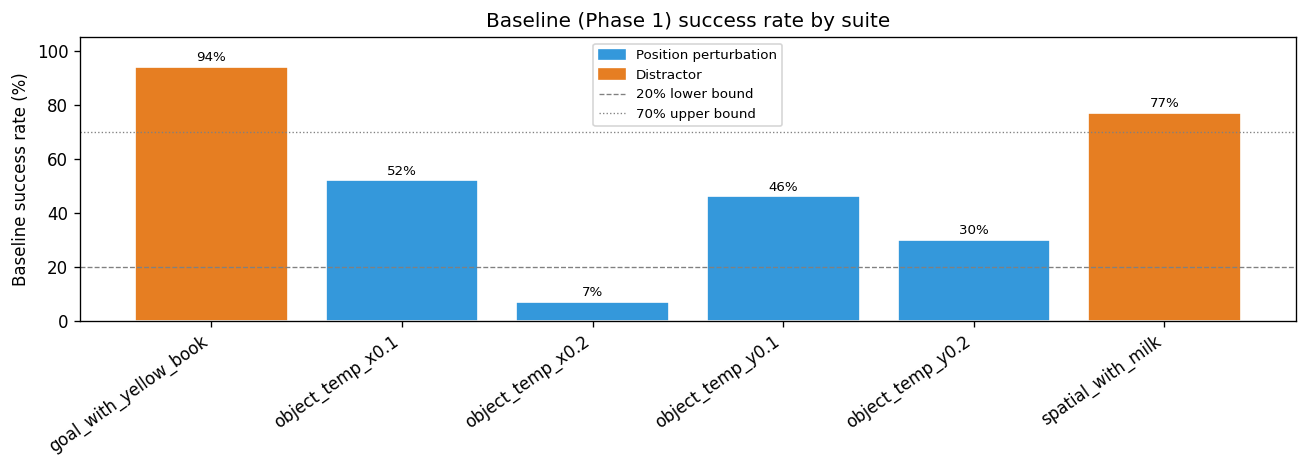

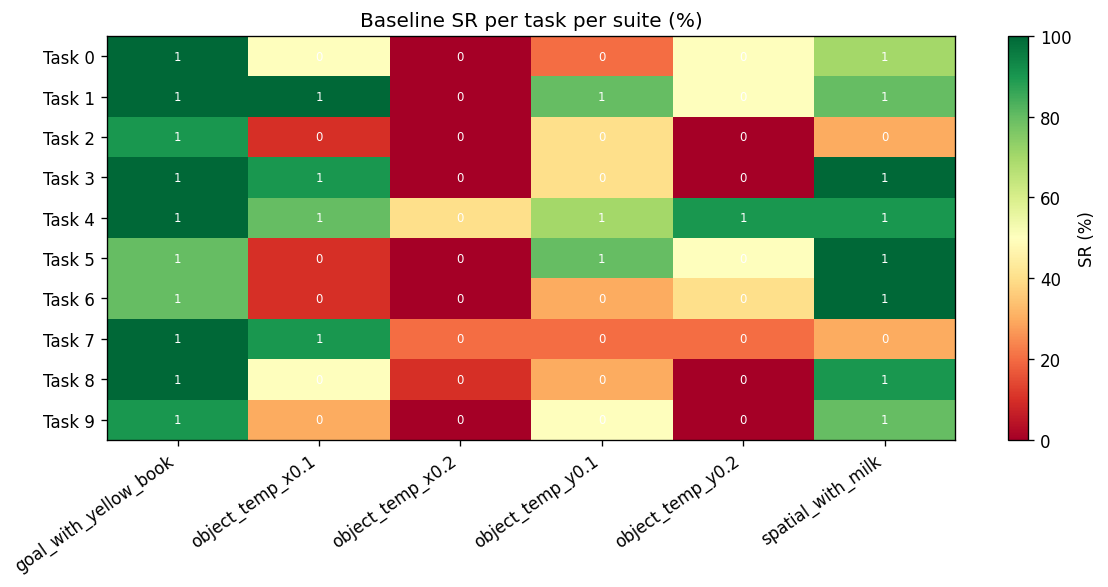

In [ ]:
suites = sorted(baseline['suite'].unique())
suite_sr = baseline.groupby('suite')['success'].mean()

# ── Suite-level bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#3498db' if 'temp_' in s else '#e67e22' for s in suite_sr.index]
bars = ax.bar(range(len(suite_sr)), suite_sr.values * 100, color=colors, edgecolor='white')
ax.axhline(20, color='gray', ls='--', lw=0.8, label='20% lower bound')
ax.axhline(70, color='gray', ls=':',  lw=0.8, label='70% upper bound')
ax.set_xticks(range(len(suite_sr)))
ax.set_xticklabels([s.replace('libero_','') for s in suite_sr.index], rotation=35, ha='right')
ax.set_ylabel('Baseline success rate (%)')
ax.set_ylim(0, 105)
ax.set_title('Baseline (Phase 1) success rate by suite')
for bar, v in zip(bars, suite_sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{v:.0%}', ha='center', va='bottom', fontsize=8)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#3498db', label='Position perturbation'),
    Patch(color='#e67e22', label='Distractor'),
] + ax.get_legend_handles_labels()[0], fontsize=8)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/baseline_sr_by_suite.png', dpi=150)
plt.show()

# ── Per-task heatmap ─────────────────────────────────────────────────────────
per_task_sr = (
    baseline.groupby(['suite', 'task_idx'])['success']
    .mean().unstack(level='suite').fillna(float('nan'))
)
fig, ax = plt.subplots(figsize=(max(10, len(suites) * 1.2), 5))
im = ax.imshow(per_task_sr.values * 100, aspect='auto', cmap='RdYlGn',
               vmin=0, vmax=100)
ax.set_xticks(range(len(suites)))
ax.set_xticklabels([s.replace('libero_','') for s in per_task_sr.columns],
                   rotation=35, ha='right')
ax.set_yticks(range(len(per_task_sr)))
ax.set_yticklabels([f'Task {i}' for i in per_task_sr.index])
ax.set_title('Baseline SR per task per suite (%)')
plt.colorbar(im, ax=ax, label='SR (%)')
for i in range(per_task_sr.shape[0]):
    for j in range(per_task_sr.shape[1]):
        v = per_task_sr.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                    color='black' if 30 < v < 80 else 'white')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/baseline_sr_heatmap.png', dpi=150)
plt.show()

## A3. Phase Comparison — Baseline vs. Uncertainty vs. Refinement

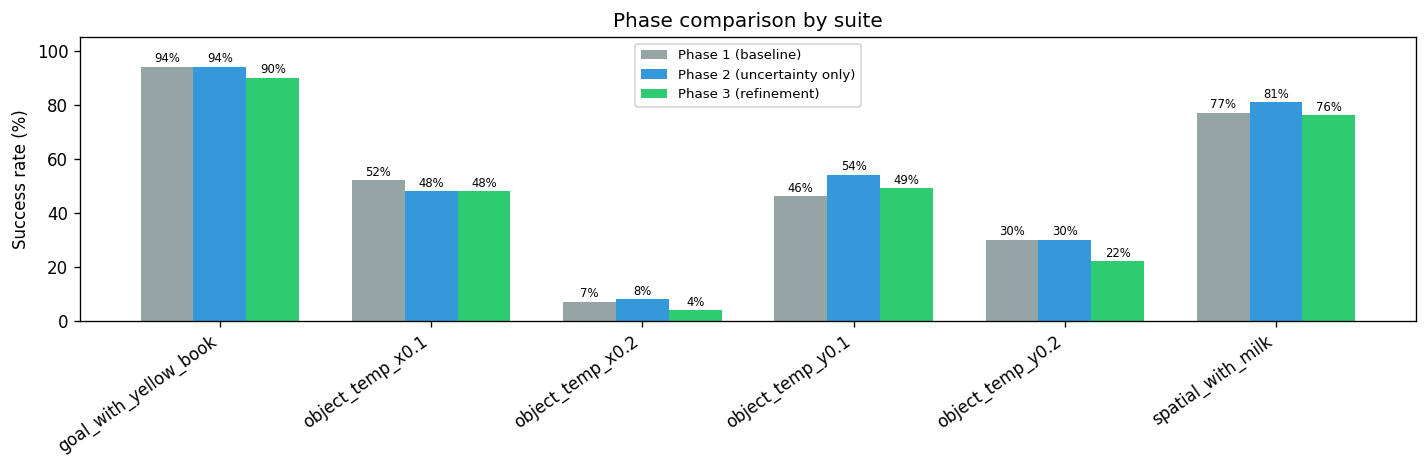

In [ ]:
if len(phase2) == 0 and len(phase3) == 0:
    print('No P&P data yet — run phases 2 and 3 first.')
else:
    suites = sorted(set(
        baseline['suite'].tolist() + phase2['suite'].tolist() + phase3['suite'].tolist()
    ))
    x  = np.arange(len(suites))
    w  = 0.25
    sr_base = baseline.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p2   = phase2.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr_p3   = phase3.groupby('suite')['success'].mean().reindex(suites).fillna(0)

    fig, ax = plt.subplots(figsize=(12, 4))
    b1 = ax.bar(x - w, sr_base * 100, width=w, label='Phase 1 (baseline)',           color='#95a5a6')
    b2 = ax.bar(x,     sr_p2   * 100, width=w, label='Phase 2 (uncertainty only)',   color='#3498db')
    b3 = ax.bar(x + w, sr_p3   * 100, width=w, label='Phase 3 (refinement)',         color='#2ecc71')
    ax.set_xticks(x)
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=35, ha='right')
    ax.set_ylabel('Success rate (%)')
    ax.set_ylim(0, 105)
    ax.set_title('Phase comparison by suite')
    ax.legend(fontsize=8)
    for bars_patch, vals in [(b1, sr_base), (b2, sr_p2), (b3, sr_p3)]:
        for bar, v in zip(bars_patch, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v*100:.0f}%', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/phase_comparison.png', dpi=150)
    plt.show()

## A4. Paired Episode Transition Analysis
For each episode, compares baseline outcome to P&P outcome (same `init_state_hash`).

Paired episodes: 600

Overall transition counts:
transition
failure → failure       246
success → success       241
success → failure  ✗     65
failure → success  ✓     48

Baseline SR:   51.0%
Refinement SR: 48.2%

Per-suite transitions:
  libero_goal_with_yellow_book               base=94%  pnp=90%  F→S=5  S→F=9
  libero_object_temp_x0.1                    base=52%  pnp=48%  F→S=10  S→F=14
  libero_object_temp_x0.2                    base=7%  pnp=4%  F→S=2  S→F=5
  libero_object_temp_y0.1                    base=46%  pnp=49%  F→S=17  S→F=14
  libero_object_temp_y0.2                    base=30%  pnp=22%  F→S=5  S→F=13
  libero_spatial_with_milk                   base=77%  pnp=76%  F→S=9  S→F=10


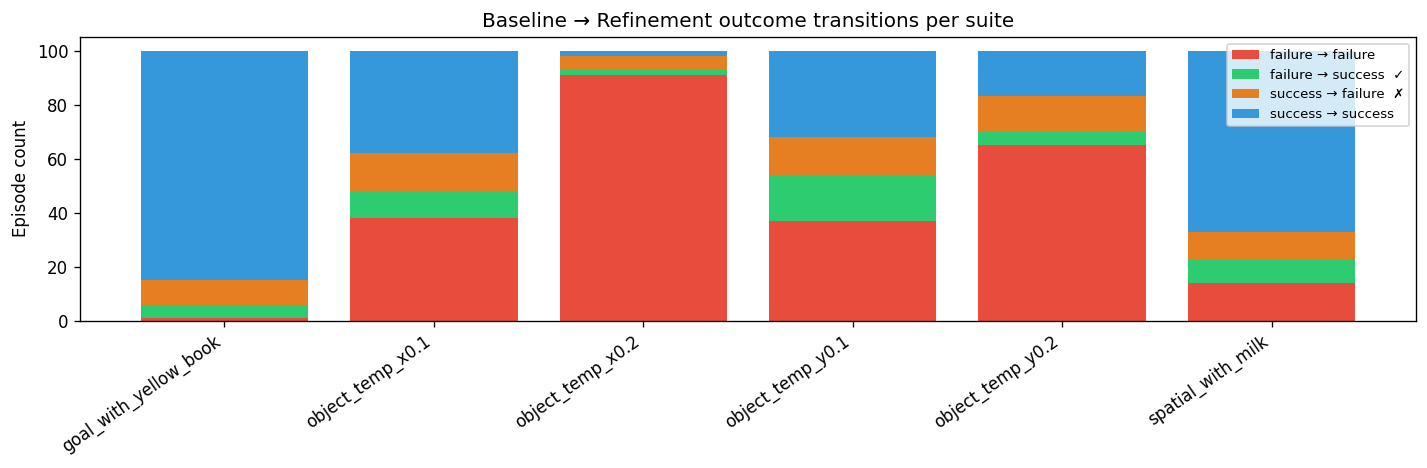

In [ ]:
if len(phase3) == 0:
    print('No Phase 3 data yet.')
else:
    # Pair baseline ↔ phase3 on (suite, task_idx, episode_idx, init_state_hash)
    b_key = baseline[['suite','task_idx','episode_idx','init_state_hash','success']].copy()
    b_key = b_key.rename(columns={'success': 'success_baseline'})
    p_key = phase3[['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']].copy()
    p_key = p_key.rename(columns={'success': 'success_pnp'})

    paired = b_key.merge(p_key, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')
    print(f'Paired episodes: {len(paired)}')

    def _transition(row):
        b, p = int(row['success_baseline']), int(row['success_pnp'])
        if b == 1 and p == 1: return 'success → success'
        if b == 0 and p == 1: return 'failure → success  ✓'
        if b == 1 and p == 0: return 'success → failure  ✗'
        return 'failure → failure'

    paired['transition'] = paired.apply(_transition, axis=1)

    # Global counts
    counts = paired['transition'].value_counts()
    print('\nOverall transition counts:')
    print(counts.to_string())
    print(f'\nBaseline SR:   {paired.success_baseline.mean():.1%}')
    print(f'Refinement SR: {paired.success_pnp.mean():.1%}')

    # Per-suite table
    print('\nPer-suite transitions:')
    for suite, grp in paired.groupby('suite'):
        tc = grp['transition'].value_counts()
        f2s = tc.get('failure → success  ✓', 0)
        s2f = tc.get('success → failure  ✗', 0)
        print(f'  {suite:<42} '
              f'base={grp.success_baseline.mean():.0%}  '
              f'pnp={grp.success_pnp.mean():.0%}  '
              f'F→S={f2s}  S→F={s2f}')

    # Transition chart per suite
    suites = sorted(paired['suite'].unique())
    cats   = ['failure → failure', 'failure → success  ✓',
              'success → failure  ✗', 'success → success']
    cat_colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

    fig, ax = plt.subplots(figsize=(12, 4))
    bottom = np.zeros(len(suites))
    for cat, color in zip(cats, cat_colors):
        vals = [
            paired[paired.suite == s]['transition'].value_counts().get(cat, 0)
            for s in suites
        ]
        ax.bar(range(len(suites)), vals, bottom=bottom, label=cat, color=color)
        bottom += np.array(vals, dtype=float)
    ax.set_xticks(range(len(suites)))
    ax.set_xticklabels([s.replace('libero_','') for s in suites], rotation=35, ha='right')
    ax.set_ylabel('Episode count')
    ax.set_title('Baseline → Refinement outcome transitions per suite')
    ax.legend(fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/transition_chart.png', dpi=150)
    plt.show()

## A5. Uncertainty vs. Outcome — Violin & Scatter Plots

In [ ]:
import sqlite3
con_check = sqlite3.connect('/content/drive/MyDrive/libero_pro_results/rollouts_jeff.db')

# Check if u_mean_episode is populated for P&P rows
rows = con_check.execute("""
    SELECT suite, pnp_mode,
           COUNT(*) as n,
           SUM(CASE WHEN u_mean_episode IS NULL THEN 1 ELSE 0 END) as null_count,
           AVG(u_mean_episode) as avg_u
    FROM rollouts
    WHERE pnp_enabled = 1
    GROUP BY suite, pnp_mode
""").fetchall()
for r in rows:
    print(r)
con_check.close()

('libero_goal_with_yellow_book', 'both', 100, 100, None)
('libero_goal_with_yellow_book', 'uncertainty', 100, 100, None)
('libero_object_temp_x0.1', 'both', 100, 100, None)
('libero_object_temp_x0.1', 'uncertainty', 112, 100, 0.06612816581683649)
('libero_object_temp_x0.2', 'both', 100, 100, None)
('libero_object_temp_x0.2', 'uncertainty', 100, 100, None)
('libero_object_temp_y0.1', 'both', 100, 100, None)
('libero_object_temp_y0.1', 'uncertainty', 100, 100, None)
('libero_object_temp_y0.2', 'both', 100, 100, None)
('libero_object_temp_y0.2', 'uncertainty', 100, 100, None)
('libero_spatial_with_milk', 'both', 100, 100, None)
('libero_spatial_with_milk', 'uncertainty', 100, 100, None)


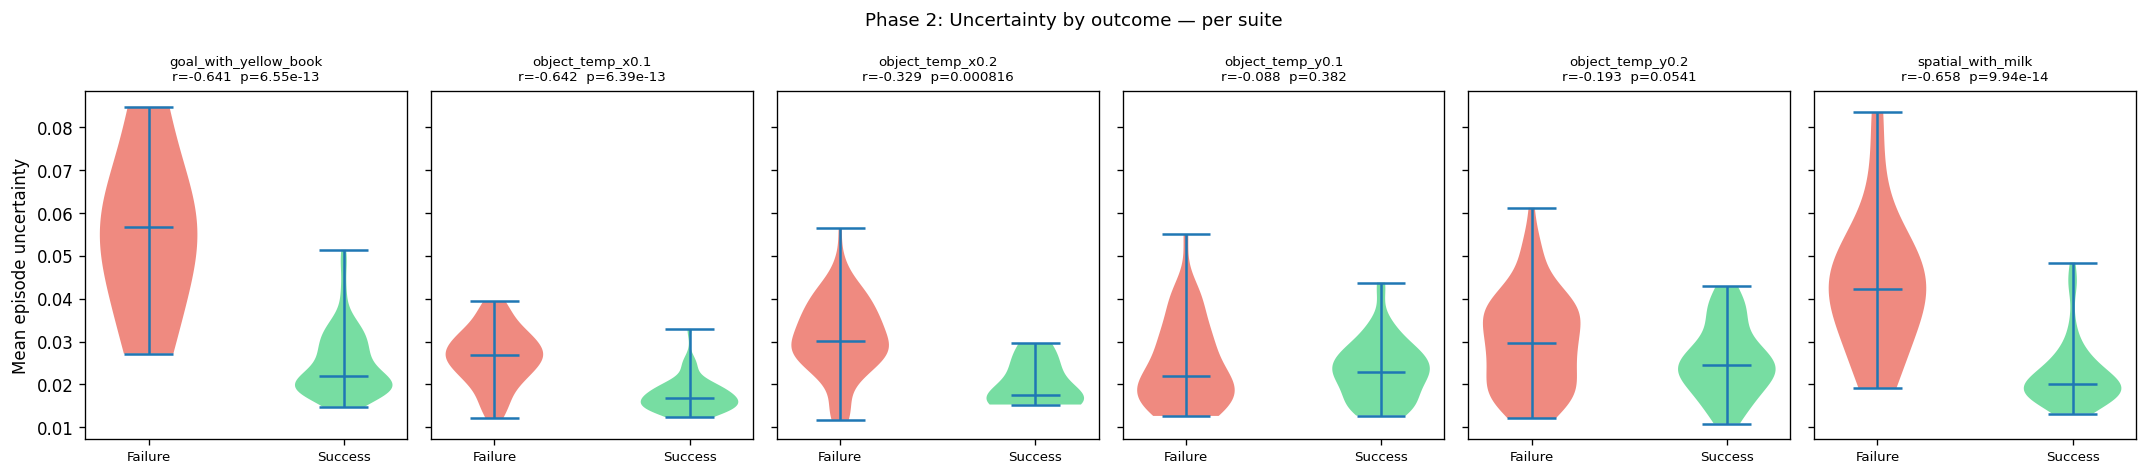

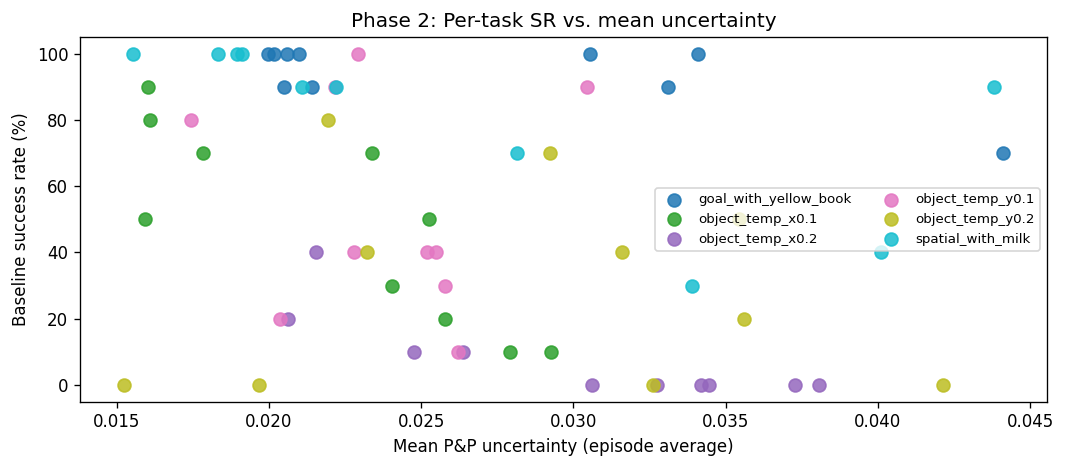

In [ ]:
if len(phase2) == 0:
    print('No Phase 2 data yet.')
else:
    suites = sorted(phase2['suite'].unique())
    n_suites = len(suites)

    # ── Violin: uncertainty by outcome, one panel per suite ──────────────────
    fig, axes = plt.subplots(1, n_suites, figsize=(3 * n_suites, 4), sharey=True)
    if n_suites == 1: axes = [axes]

    for ax, suite in zip(axes, suites):
        sub = phase2[phase2.suite == suite].dropna(subset=['u_mean_episode'])
        succ_u = sub.loc[sub.success == 1, 'u_mean_episode']
        fail_u = sub.loc[sub.success == 0, 'u_mean_episode']
        data   = [g for g in [fail_u, succ_u] if len(g) > 1]
        lbls   = [l for g, l in zip([fail_u, succ_u], ['Failure','Success']) if len(g) > 1]
        if data:
            vp = ax.violinplot(data, positions=range(len(data)), showmedians=True)
            colors = ['#e74c3c', '#2ecc71']
            for body, c in zip(vp['bodies'], colors[:len(data)]):
                body.set_facecolor(c)
                body.set_alpha(0.65)
        ax.set_xticks(range(len(lbls)))
        ax.set_xticklabels(lbls, fontsize=8)
        r, p = (pointbiserialr(sub['success'], sub['u_mean_episode'])
                if sub['success'].nunique() == 2 else (float('nan'), float('nan')))
        ax.set_title(f'{suite.replace("libero_","")}\nr={r:.3f}  p={p:.3g}', fontsize=8)
        if ax is axes[0]:
            ax.set_ylabel('Mean episode uncertainty')

    fig.suptitle('Phase 2: Uncertainty by outcome — per suite', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/uncertainty_by_outcome_violin.png', dpi=150)
    plt.show()

    # ── Per-task scatter: SR vs. mean uncertainty ─────────────────────────────
    per_task = (
        phase2.groupby(['suite','task_idx'])
        .agg(sr=('success','mean'), u_mean=('u_mean_episode','mean'), n=('success','count'))
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(9, 4))
    colors_suite = plt.cm.tab10(np.linspace(0, 1, len(suites)))
    for (suite, color) in zip(suites, colors_suite):
        g = per_task[per_task.suite == suite]
        ax.scatter(g['u_mean'], g['sr'] * 100, color=color,
                   s=60, alpha=0.85, label=suite.replace('libero_',''), zorder=3)
    ax.set_xlabel('Mean P&P uncertainty (episode average)')
    ax.set_ylabel('Baseline success rate (%)')
    ax.set_title('Phase 2: Per-task SR vs. mean uncertainty')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/sr_vs_uncertainty_scatter.png', dpi=150)
    plt.show()

Paired episodes: 600
suite
libero_goal_with_yellow_book    100
libero_object_temp_x0.1         100
libero_object_temp_x0.2         100
libero_object_temp_y0.1         100
libero_object_temp_y0.2         100
libero_spatial_with_milk        100
dtype: int64


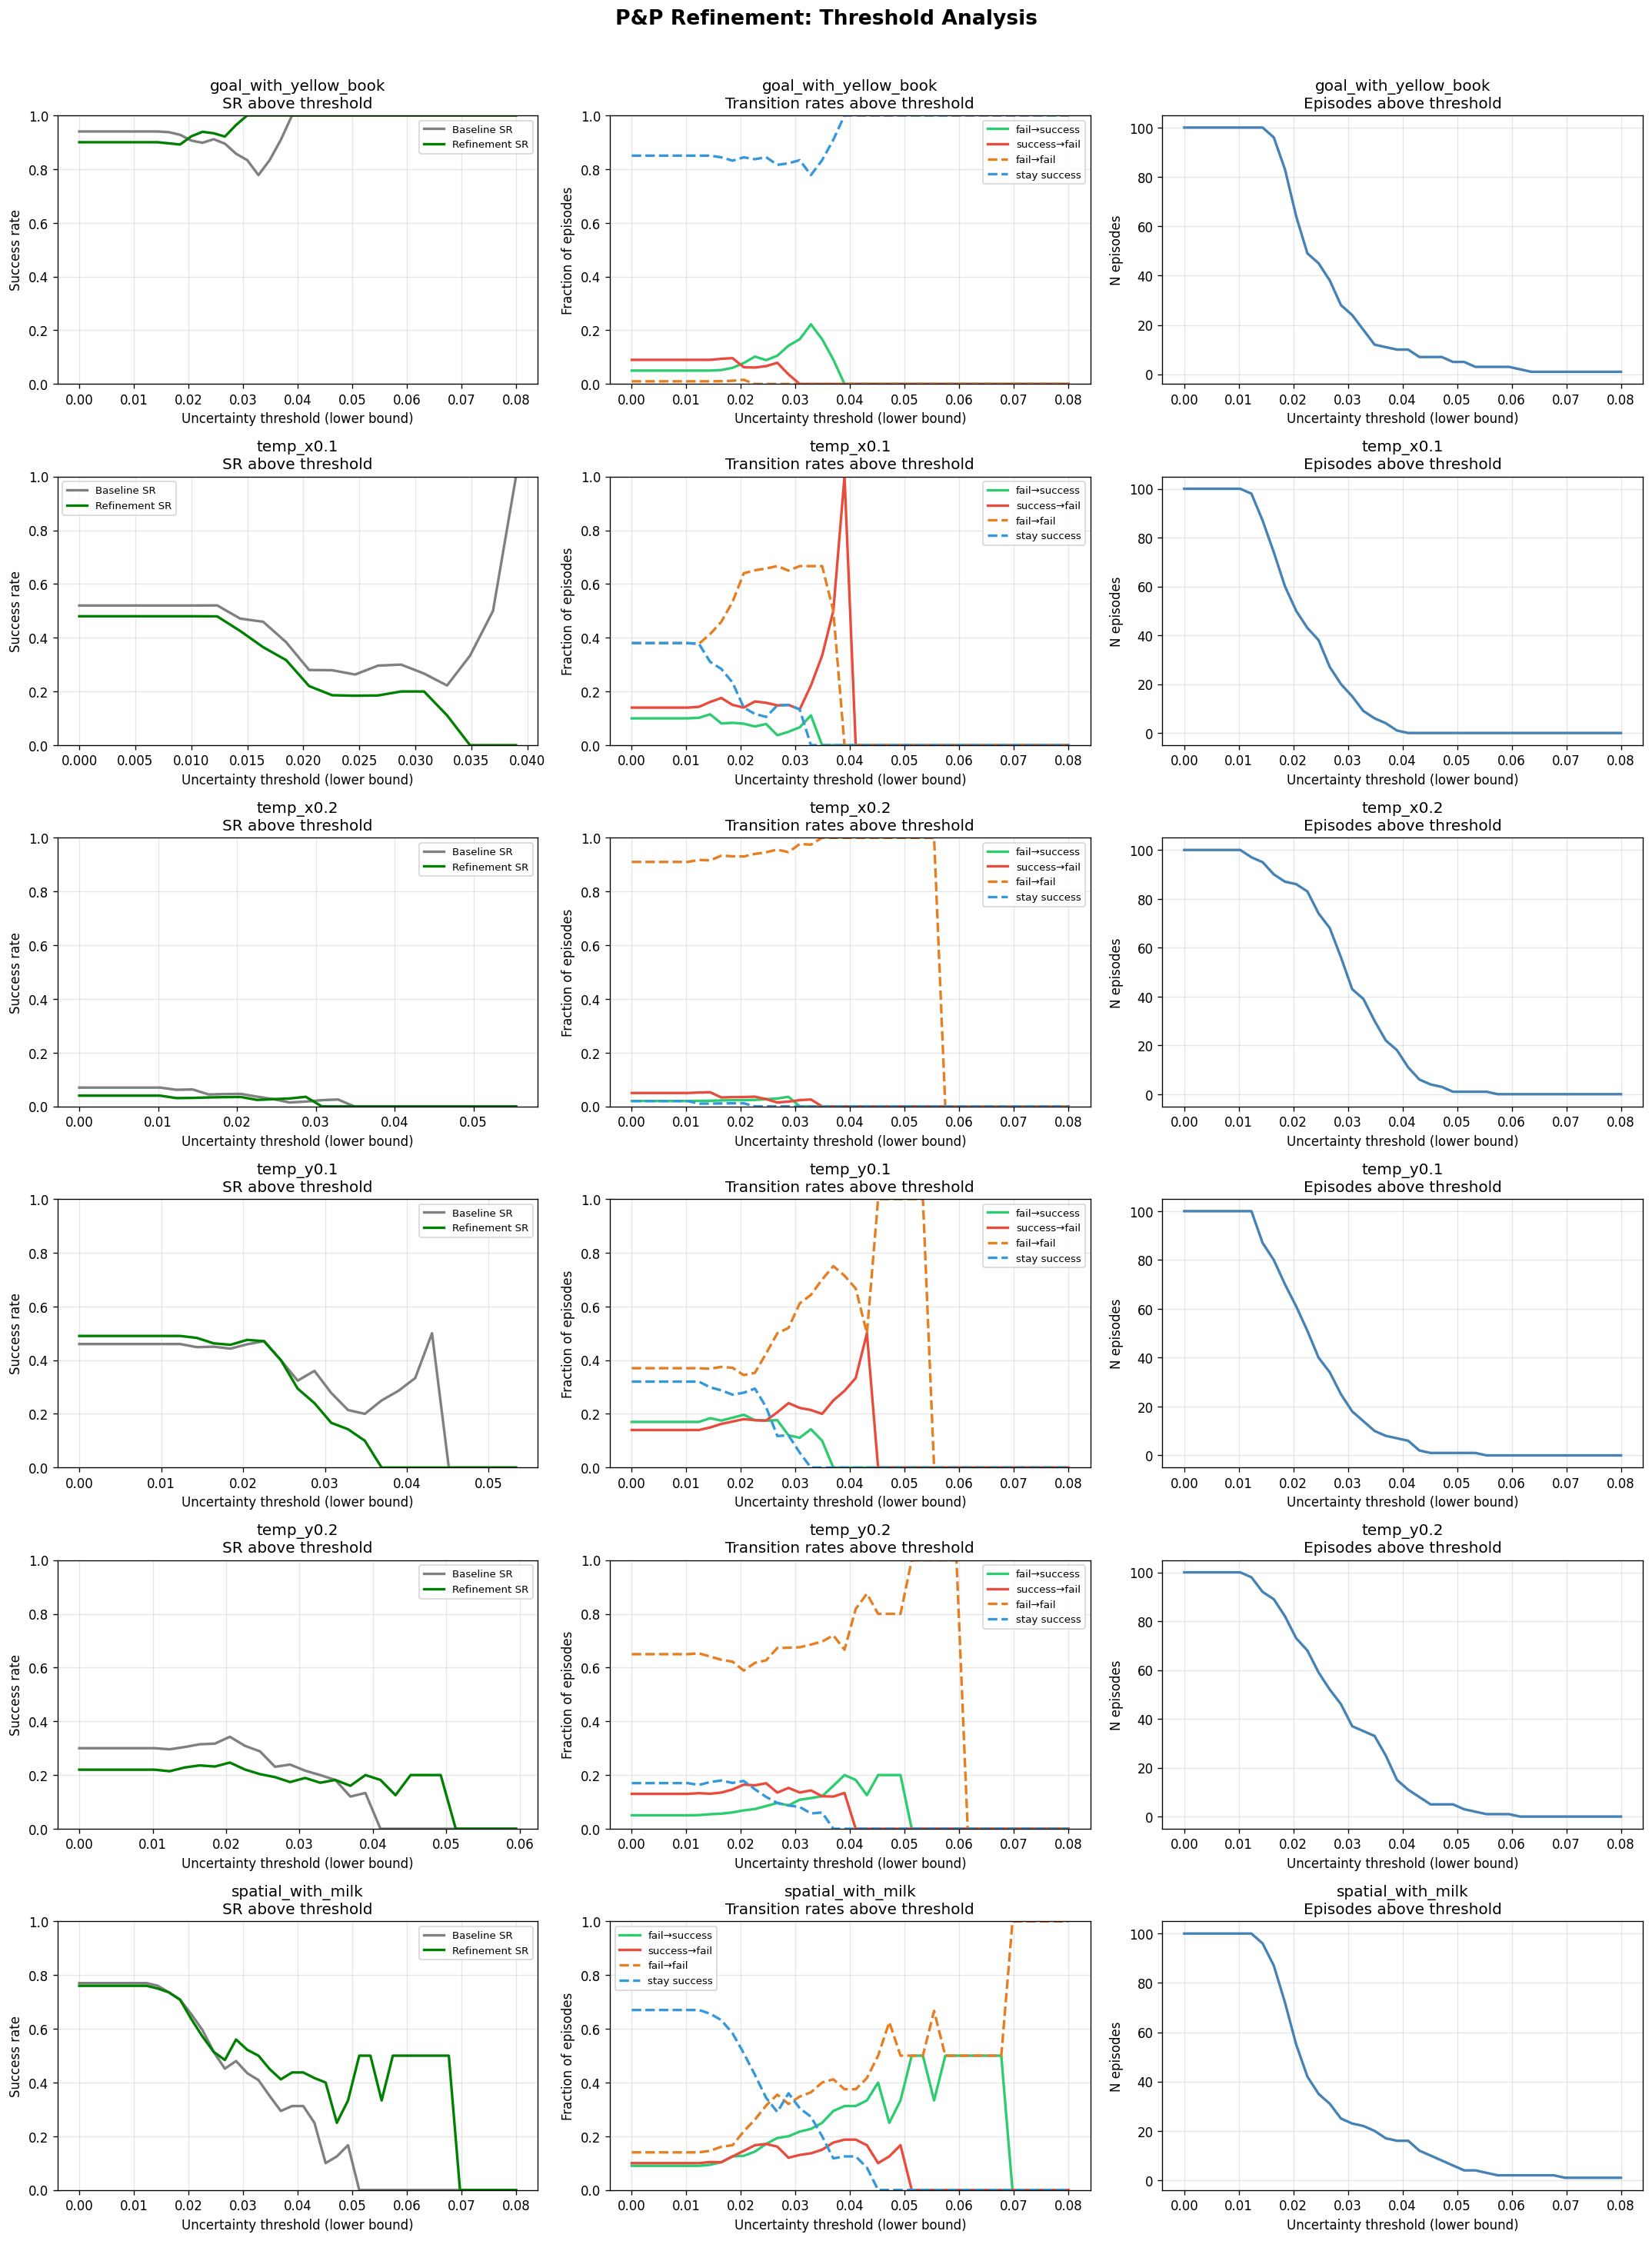

Saved to Drive.


In [ ]:
import sqlite3, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DB_PATH_JEFF = '/content/drive/MyDrive/libero_pro_results/rollouts_jeff_2.db'
con = sqlite3.connect(DB_PATH_JEFF)

df = pd.read_sql('SELECT * FROM rollouts', con)
con.close()

# Pair baseline and refinement on (suite, task_idx, episode_idx, init_state_hash)
base = df[df.pnp_enabled == 0][['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled == 1) & (df.pnp_mode == 'uncertainty')]\
         [['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']]\
         .rename(columns={'success':'unc_success'})
ref  = df[(df.pnp_enabled == 1) & (df.pnp_mode == 'both')]\
         [['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'ref_success'})

# Merge all three phases
paired = base.merge(unc,  on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')\
             .merge(ref,  on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')

print(f'Paired episodes: {len(paired)}')
print(paired.groupby('suite').size())

# ── Threshold sweep ───────────────────────────────────────────────────────────
thresholds = np.linspace(0.0, 0.08, 40)
SUITES = sorted(paired['suite'].unique())
COLORS = {'fail->success': '#2ecc71', 'success->fail': '#e74c3c',
          'fail->fail': '#e67e22', 'success->success': '#3498db'}

fig, axes = plt.subplots(len(SUITES), 3, figsize=(18, 4*len(SUITES)))
fig.suptitle('P&P Refinement: Threshold Analysis', fontsize=16, fontweight='bold', y=1.01)

for i, suite in enumerate(SUITES):
    s = paired[paired.suite == suite].copy()
    short = suite.replace('libero_','').replace('object_','')

    # Arrays for threshold sweep
    n_above      = []
    sr_base      = []
    sr_ref       = []
    fail2success = []
    success2fail = []
    fail2fail    = []
    success2success = []

    for t in thresholds:
        above = s[s.u_mean_episode >= t]
        n_above.append(len(above))
        if len(above) == 0:
            sr_base.append(np.nan); sr_ref.append(np.nan)
            fail2success.append(0); success2fail.append(0)
            fail2fail.append(0); success2success.append(0)
            continue
        sr_base.append(above.base_success.mean())
        sr_ref.append(above.ref_success.mean())
        fail2success.append(((above.base_success==0) & (above.ref_success==1)).sum() / len(above))
        success2fail.append(((above.base_success==1) & (above.ref_success==0)).sum() / len(above))
        fail2fail.append(((above.base_success==0) & (above.ref_success==0)).sum() / len(above))
        success2success.append(((above.base_success==1) & (above.ref_success==1)).sum() / len(above))

    # Plot 1: SR vs threshold
    ax1 = axes[i, 0]
    ax1.plot(thresholds, sr_base, color='gray', label='Baseline SR', linewidth=2)
    ax1.plot(thresholds, sr_ref,  color='green', label='Refinement SR', linewidth=2)
    ax1.set_xlabel('Uncertainty threshold (lower bound)')
    ax1.set_ylabel('Success rate')
    ax1.set_title(f'{short}\nSR above threshold')
    ax1.legend(fontsize=8)
    ax1.set_ylim(0, 1)
    ax1.grid(alpha=0.3)

    # Plot 2: Transition rates vs threshold
    ax2 = axes[i, 1]
    ax2.plot(thresholds, fail2success,    color=COLORS['fail->success'],    label='fail→success', linewidth=2)
    ax2.plot(thresholds, success2fail,    color=COLORS['success->fail'],    label='success→fail', linewidth=2)
    ax2.plot(thresholds, fail2fail,       color=COLORS['fail->fail'],       label='fail→fail',    linewidth=2, linestyle='--')
    ax2.plot(thresholds, success2success, color=COLORS['success->success'], label='stay success', linewidth=2, linestyle='--')
    ax2.set_xlabel('Uncertainty threshold (lower bound)')
    ax2.set_ylabel('Fraction of episodes')
    ax2.set_title(f'{short}\nTransition rates above threshold')
    ax2.legend(fontsize=8)
    ax2.set_ylim(0, 1)
    ax2.grid(alpha=0.3)

    # Plot 3: N episodes above threshold
    ax3 = axes[i, 2]
    ax3.plot(thresholds, n_above, color='steelblue', linewidth=2)
    ax3.set_xlabel('Uncertainty threshold (lower bound)')
    ax3.set_ylabel('N episodes')
    ax3.set_title(f'{short}\nEpisodes above threshold')
    ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/libero_pro_results/threshold_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Drive.')

Total paired episodes: 600
Overall baseline SR:   0.510


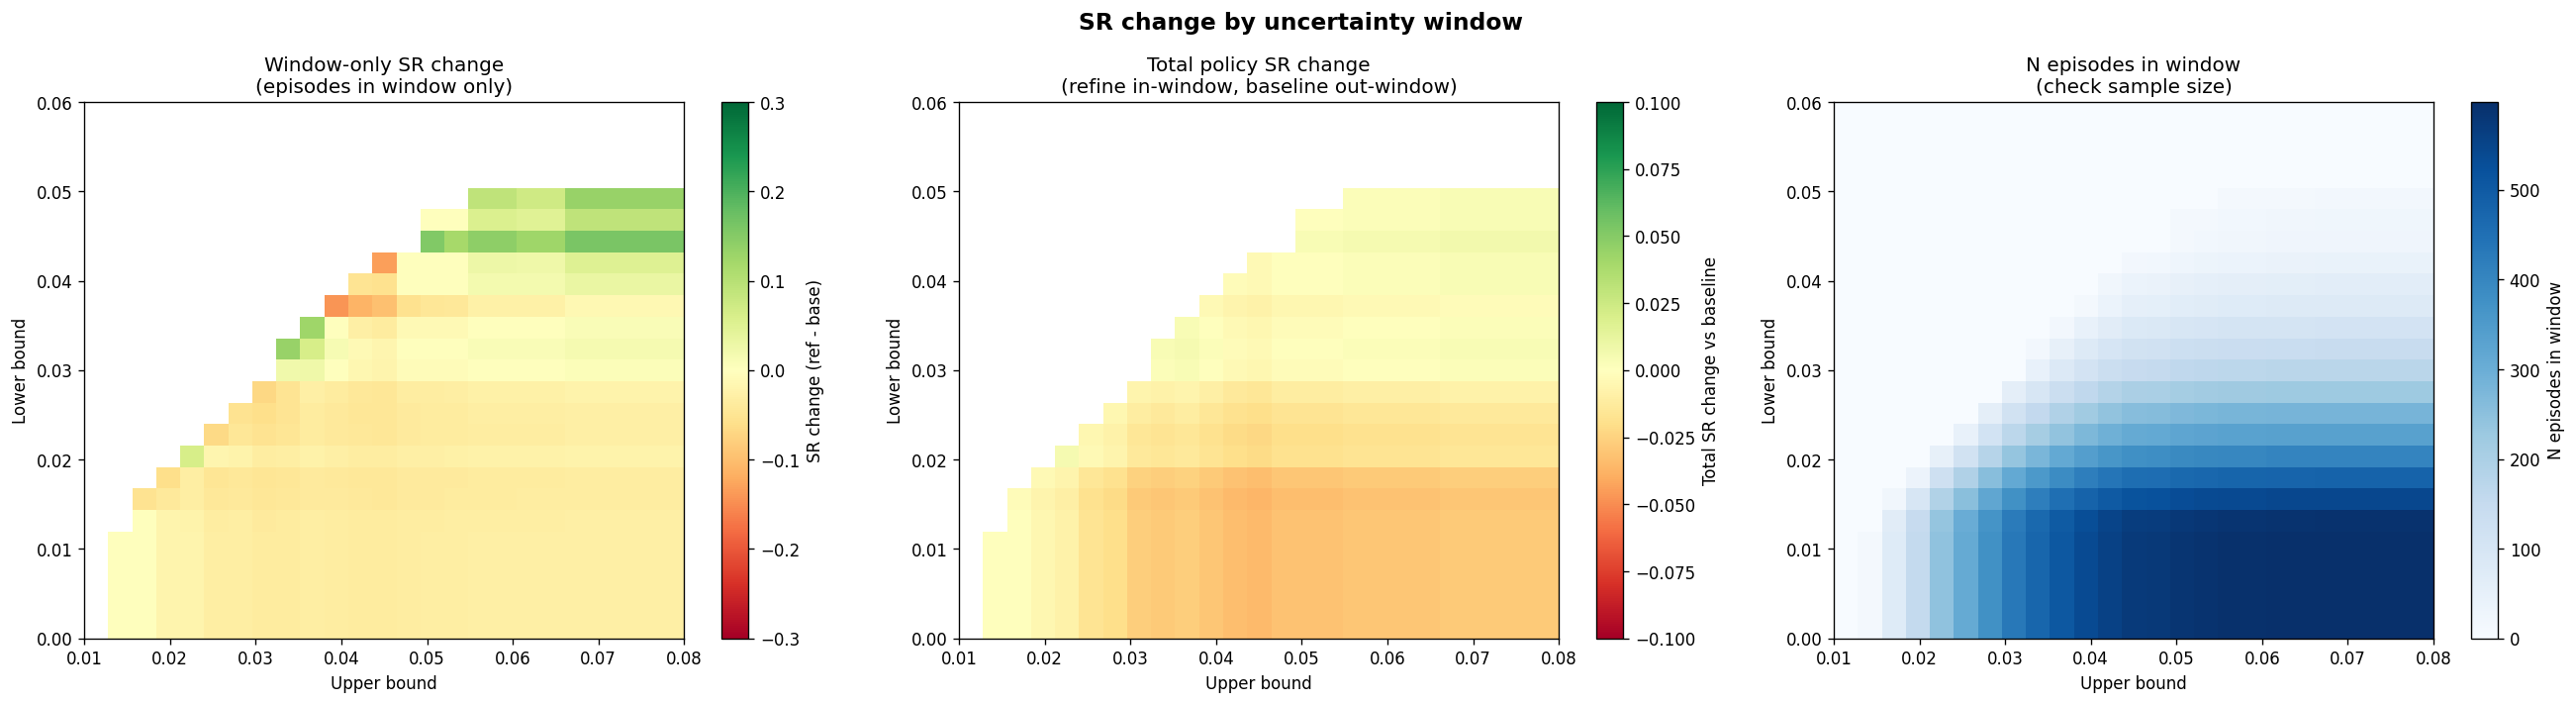


Overall baseline SR: 0.510

TOP 10 windows by WINDOW SR change:
   Lower    Upper      N  Win SR chg  Tot SR chg  Base SR   Ref SR
-----------------------------------------------------------------
   0.045    0.068     25      +0.160      +0.007    0.280    0.440
   0.045    0.071     25      +0.160      +0.007    0.280    0.440
   0.045    0.074     25      +0.160      +0.007    0.280    0.440
   0.045    0.077     25      +0.160      +0.007    0.280    0.440
   0.045    0.080     25      +0.160      +0.007    0.280    0.440
   0.045    0.057     21      +0.143      +0.005    0.238    0.381
   0.045    0.060     21      +0.143      +0.005    0.238    0.381
   0.045    0.062     24      +0.125      +0.005    0.292    0.417
   0.045    0.065     24      +0.125      +0.005    0.292    0.417
   0.048    0.068     22      +0.091      +0.003    0.318    0.409

TOP 10 windows by TOTAL POLICY SR change:
   Lower    Upper      N  Win SR chg  Tot SR chg  Base SR   Ref SR
----------------------

In [ ]:
import sqlite3, numpy as np, pandas as pd
import matplotlib.pyplot as plt

DB_PATH_JEFF = '/content/drive/MyDrive/libero_pro_results/rollouts_jeff_2.db'
con = sqlite3.connect(DB_PATH_JEFF)
df = pd.read_sql('SELECT * FROM rollouts', con)
con.close()

# Pair phases
base = df[df.pnp_enabled==0][['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'base_success'})
unc  = df[(df.pnp_enabled==1)&(df.pnp_mode=='uncertainty')]\
         [['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']]\
         .rename(columns={'success':'unc_success'})
ref  = df[(df.pnp_enabled==1)&(df.pnp_mode=='both')]\
         [['suite','task_idx','episode_idx','init_state_hash','success']]\
         .rename(columns={'success':'ref_success'})

paired = base.merge(unc, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')\
             .merge(ref, on=['suite','task_idx','episode_idx','init_state_hash'], how='inner')

total_n = len(paired)
overall_base_sr = paired.base_success.mean()
print(f'Total paired episodes: {total_n}')
print(f'Overall baseline SR:   {overall_base_sr:.3f}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
lower_bounds = np.linspace(0.0, 0.06, 25)
upper_bounds = np.linspace(0.01, 0.08, 25)

# Window-only SR change
sr_change_window   = np.full((len(lower_bounds), len(upper_bounds)), np.nan)
# Total SR change (selective refinement policy)
sr_change_total    = np.full((len(lower_bounds), len(upper_bounds)), np.nan)
n_episodes         = np.zeros((len(lower_bounds), len(upper_bounds)))

for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if hi <= lo:
            continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode < lo)  | (paired.u_mean_episode > hi)]
        if len(in_window) < 10:
            continue

        n_episodes[i, j] = len(in_window)

        # Window-only: SR change just for episodes in window
        sr_change_window[i, j] = in_window.ref_success.mean() - in_window.base_success.mean()

        # Total policy: refine in-window, keep baseline for out-window
        successes_in  = in_window.ref_success.sum()
        successes_out = out_window.base_success.sum()
        total_sr_policy = (successes_in + successes_out) / total_n
        sr_change_total[i, j] = total_sr_policy - overall_base_sr

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('SR change by uncertainty window', fontsize=14, fontweight='bold')

# Plot 1: Window-only SR change
im1 = axes[0].imshow(sr_change_window, aspect='auto', origin='lower',
                      cmap='RdYlGn', vmin=-0.3, vmax=0.3,
                      extent=[upper_bounds[0], upper_bounds[-1],
                               lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im1, ax=axes[0], label='SR change (ref - base)')
axes[0].set_xlabel('Upper bound')
axes[0].set_ylabel('Lower bound')
axes[0].set_title('Window-only SR change\n(episodes in window only)')

# Plot 2: Total policy SR change
im2 = axes[1].imshow(sr_change_total, aspect='auto', origin='lower',
                      cmap='RdYlGn', vmin=-0.1, vmax=0.1,
                      extent=[upper_bounds[0], upper_bounds[-1],
                               lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im2, ax=axes[1], label='Total SR change vs baseline')
axes[1].set_xlabel('Upper bound')
axes[1].set_ylabel('Lower bound')
axes[1].set_title('Total policy SR change\n(refine in-window, baseline out-window)')

# Plot 3: N episodes in window
im3 = axes[2].imshow(n_episodes, aspect='auto', origin='lower',
                      cmap='Blues',
                      extent=[upper_bounds[0], upper_bounds[-1],
                               lower_bounds[0], lower_bounds[-1]])
plt.colorbar(im3, ax=axes[2], label='N episodes in window')
axes[2].set_xlabel('Upper bound')
axes[2].set_ylabel('Lower bound')
axes[2].set_title('N episodes in window\n(check sample size)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/libero_pro_results/threshold_2d_heatmap_v2.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top/bottom windows ────────────────────────────────────────────────────────
results = []
for i, lo in enumerate(lower_bounds):
    for j, hi in enumerate(upper_bounds):
        if np.isnan(sr_change_window[i,j]) or n_episodes[i,j] < 20:
            continue
        in_window  = paired[(paired.u_mean_episode >= lo) & (paired.u_mean_episode <= hi)]
        out_window = paired[(paired.u_mean_episode < lo)  | (paired.u_mean_episode > hi)]
        successes_in  = in_window.ref_success.sum()
        successes_out = out_window.base_success.sum()
        total_sr_policy = (successes_in + successes_out) / total_n
        results.append({
            'lo': lo, 'hi': hi, 'n': len(in_window),
            'window_sr_change': sr_change_window[i,j],
            'total_sr_change':  total_sr_policy - overall_base_sr,
            'base_sr_window':   in_window.base_success.mean(),
            'ref_sr_window':    in_window.ref_success.mean(),
            'total_sr_policy':  total_sr_policy,
        })

results_df = pd.DataFrame(results)

print(f'\nOverall baseline SR: {overall_base_sr:.3f}')
print(f'\n{"==="*20}')
print('TOP 10 windows by WINDOW SR change:')
print(f'{"Lower":>8} {"Upper":>8} {"N":>6} {"Win SR chg":>11} {"Tot SR chg":>11} {"Base SR":>8} {"Ref SR":>8}')
print('-' * 65)
for _, r in results_df.nlargest(10, 'window_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.window_sr_change:>+11.3f} {r.total_sr_change:>+11.3f} '
          f'{r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

print(f'\n{"==="*20}')
print('TOP 10 windows by TOTAL POLICY SR change:')
print(f'{"Lower":>8} {"Upper":>8} {"N":>6} {"Win SR chg":>11} {"Tot SR chg":>11} {"Base SR":>8} {"Ref SR":>8}')
print('-' * 65)
for _, r in results_df.nlargest(10, 'total_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.window_sr_change:>+11.3f} {r.total_sr_change:>+11.3f} '
          f'{r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

print(f'\n{"==="*20}')
print('BOTTOM 10 windows by TOTAL POLICY SR change (most degradation):')
print(f'{"Lower":>8} {"Upper":>8} {"N":>6} {"Win SR chg":>11} {"Tot SR chg":>11} {"Base SR":>8} {"Ref SR":>8}')
print('-' * 65)
for _, r in results_df.nsmallest(10, 'total_sr_change').iterrows():
    print(f'{r.lo:>8.3f} {r.hi:>8.3f} {r.n:>6.0f} '
          f'{r.window_sr_change:>+11.3f} {r.total_sr_change:>+11.3f} '
          f'{r.base_sr_window:>8.3f} {r.ref_sr_window:>8.3f}')

In [ ]:
import shutil, os

# ── Config ────────────────────────────────────────────────────────────────────
# Your current Drive paths
CURRENT_CACHE    = '/content/drive/MyDrive/smolvla_colab_cache'
CURRENT_RESULTS  = '/content/drive/MyDrive/libero_pro_results'

# Shared Drive destination — change this to your shared Drive folder path
# e.g. '/content/drive/Shareddrives/CS159_Project' or a shared folder
SHARED_BASE      = '/content/drive/MyDrive/cs159_shared'

DST_CACHE   = os.path.join(SHARED_BASE, 'smolvla_colab_cache')
DST_RESULTS = os.path.join(SHARED_BASE, 'libero_pro_results')

os.makedirs(SHARED_BASE, exist_ok=True)

# ── Copy cache ────────────────────────────────────────────────────────────────
if os.path.exists(CURRENT_CACHE):
    if os.path.exists(DST_CACHE):
        print(f'Cache already exists at {DST_CACHE}, skipping.')
    else:
        print('Copying cache (this may take a few minutes)...')
        shutil.copytree(CURRENT_CACHE, DST_CACHE)
        print(f'Cache copied to {DST_CACHE}')
else:
    print(f'WARNING: cache not found at {CURRENT_CACHE}')

# ── Copy results (DB + init files backup) ─────────────────────────────────────
if os.path.exists(CURRENT_RESULTS):
    if os.path.exists(DST_RESULTS):
        print(f'Results already exists at {DST_RESULTS}, skipping.')
    else:
        print('Copying results...')
        shutil.copytree(CURRENT_RESULTS, DST_RESULTS)
        print(f'Results copied to {DST_RESULTS}')
else:
    print(f'WARNING: results not found at {CURRENT_RESULTS}')

# ── Verify ────────────────────────────────────────────────────────────────────
print('\nShared folder contents:')
for root, dirs, files in os.walk(SHARED_BASE):
    depth = root.replace(SHARED_BASE, '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    if depth < 2:
        for f in files:
            size_mb = os.path.getsize(os.path.join(root, f)) / 1e6
            print(f'{indent}  {f} ({size_mb:.1f} MB)')

print(f'\nDone. Share the folder at {SHARED_BASE} with the new account.')
print('The new account should update DRIVE_BASE in the notebook to point to this folder.')

Copying cache (this may take a few minutes)...
Cache copied to /content/drive/MyDrive/cs159_shared/smolvla_colab_cache
Copying results...
Results copied to /content/drive/MyDrive/cs159_shared/libero_pro_results

Shared folder contents:
cs159_shared/
  smolvla_colab_cache/
    site_packages.tar.gz (11198.5 MB)
    libero_pro_files.tar.gz (0.7 MB)
    hf_models/
      hub/
        models--HuggingFaceVLA--smolvla_libero/
          refs/
          blobs/
          snapshots/
            6721902bc4d61e50a3bfdb11dfb4cb626f05d102/
          .no_exist/
            6721902bc4d61e50a3bfdb11dfb4cb626f05d102/
        .locks/
          models--HuggingFaceVLA--smolvla_libero/
          models--HuggingFaceTB--SmolVLM2-500M-Instruct/
          models--lerobot--pi05_libero_finetuned/
          models--google--paligemma-3b-pt-224/
        models--HuggingFaceTB--SmolVLM2-500M-Instruct/
          blobs/
          snapshots/
            7b375e1b73b11138ff12fe22c8f2822d8fe03467/
          refs/
          .n

## A6. ROC / AUC — Uncertainty as Failure Predictor

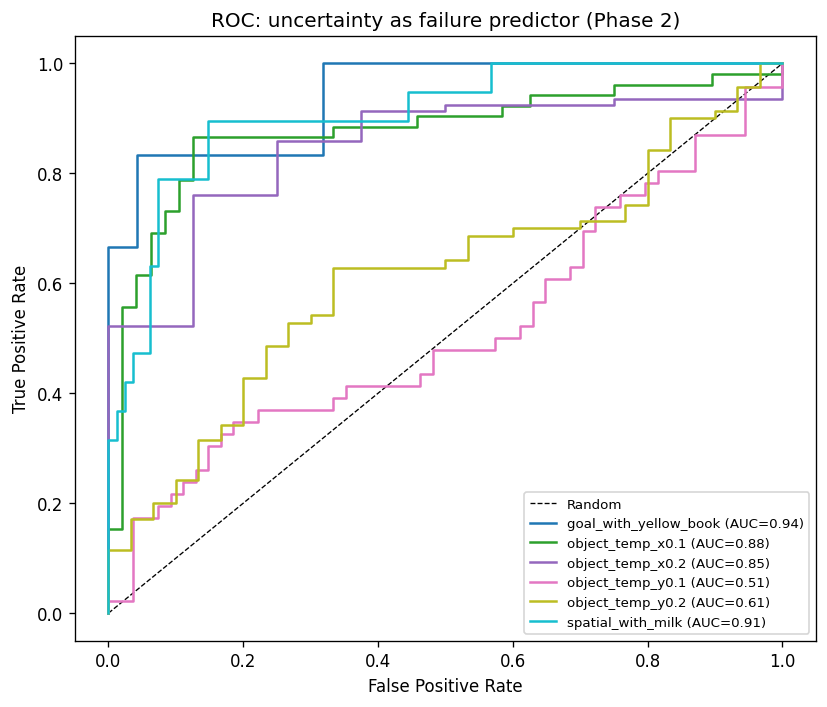


AUC by suite:
  libero_goal_with_yellow_book                  AUC=0.940  [distractor]
  libero_spatial_with_milk                      AUC=0.906  [distractor]
  libero_object_temp_x0.1                       AUC=0.876  [pos_perturb]
  libero_object_temp_x0.2                       AUC=0.846  [pos_perturb]
  libero_object_temp_y0.2                       AUC=0.610  [pos_perturb]
  libero_object_temp_y0.1                       AUC=0.513  [pos_perturb]

Mean AUC across suites: 0.782


In [ ]:
if len(phase2) == 0:
    print('No Phase 2 data yet.')
else:
    sub = phase2.dropna(subset=['u_mean_episode'])
    suites = sorted(sub['suite'].unique())

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot([0,1],[0,1],'k--',lw=0.8, label='Random')

    auc_results = {}
    colors_suite = plt.cm.tab10(np.linspace(0, 1, len(suites)))

    for suite, color in zip(suites, colors_suite):
        g = sub[sub.suite == suite]
        if g['success'].nunique() < 2:
            print(f'  Skipping {suite}: only one outcome class present')
            continue
        # Higher uncertainty → predicts failure (success=0)
        fpr, tpr, _ = roc_curve(1 - g['success'], g['u_mean_episode'])
        roc_auc = auc(fpr, tpr)
        auc_results[suite] = roc_auc
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{suite.replace("libero_","")} (AUC={roc_auc:.2f})')

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC: uncertainty as failure predictor (Phase 2)')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/roc_curves.png', dpi=150)
    plt.show()

    print('\nAUC by suite:')
    for suite, a_val in sorted(auc_results.items(), key=lambda x: -x[1]):
        stype = 'pos_perturb' if 'temp_' in suite else 'distractor'
        print(f'  {suite:<45} AUC={a_val:.3f}  [{stype}]')

    if auc_results:
        overall_auc = np.mean(list(auc_results.values()))
        print(f'\nMean AUC across suites: {overall_auc:.3f}')

## A7. Uncertainty by Euler Step

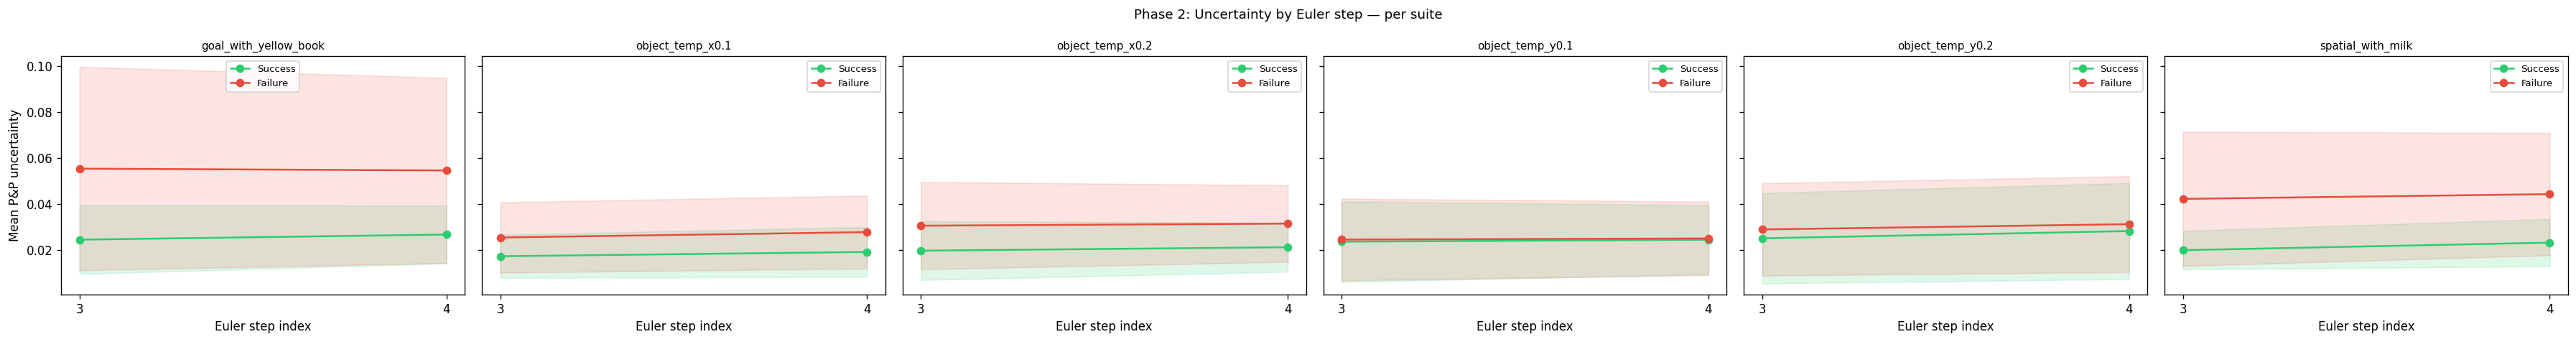

Point-biserial r (uncertainty ↔ failure) per Euler step:
 euler_step         r            p    n
          3 -0.189821 2.941818e-23 2692
          4 -0.180622 3.557415e-21 2692


In [ ]:
if len(steps_p2) == 0:
    print('No Phase 2 Euler step data yet.')
else:
    # Join outcome labels
    steps_j = steps_p2.merge(
        phase2[['rollout_id','success','suite']], on='rollout_id', how='left')

    suites = sorted(steps_j['suite'].dropna().unique())
    n_suites = len(suites)

    fig, axes = plt.subplots(1, n_suites, figsize=(5 * n_suites, 4), sharey=True)
    if n_suites == 1: axes = [axes]

    for ax, suite in zip(axes, suites):
        sub = steps_j[steps_j.suite == suite]
        by_e = (sub.groupby(['euler_step','success'])
                .agg(u_mean=('u_mean','mean'), u_std=('u_mean','std'))
                .reset_index())
        for outcome, label, color in [(1,'Success','#2ecc71'), (0,'Failure','#e74c3c')]:
            g = by_e[by_e.success == outcome].sort_values('euler_step')
            if g.empty: continue
            ax.plot(g['euler_step'], g['u_mean'], marker='o', color=color, label=label)
            ax.fill_between(g['euler_step'],
                            g['u_mean'] - g['u_std'].fillna(0),
                            g['u_mean'] + g['u_std'].fillna(0),
                            alpha=0.15, color=color)
        ax.set_xlabel('Euler step index')
        if ax is axes[0]: ax.set_ylabel('Mean P&P uncertainty')
        ax.set_title(suite.replace('libero_',''), fontsize=9)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8)

    fig.suptitle('Phase 2: Uncertainty by Euler step — per suite', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/uncertainty_by_euler_step.png', dpi=150)
    plt.show()

    # Point-biserial discriminability per step
    print('Point-biserial r (uncertainty ↔ failure) per Euler step:')
    step_corrs = []
    for step_idx, grp in steps_j.groupby('euler_step'):
        if grp['success'].nunique() < 2: continue
        r, p = pointbiserialr(grp['success'], grp['u_mean'])
        step_corrs.append({'euler_step': step_idx, 'r': r, 'p': p, 'n': len(grp)})
    sc_df = pd.DataFrame(step_corrs).sort_values('euler_step')
    print(sc_df.to_string(index=False))

## A8. Uncertainty Over Episode Time

/tmp/ipykernel_567/2683648873.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = (sub.groupby(['time_bin','success'])
/tmp/ipykernel_567/2683648873.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = (sub.groupby(['time_bin','success'])
/tmp/ipykernel_567/2683648873.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_bin = (sub.groupby(['time_bin','success'])
/tmp/ipykernel_567/2683648873.py:24: 

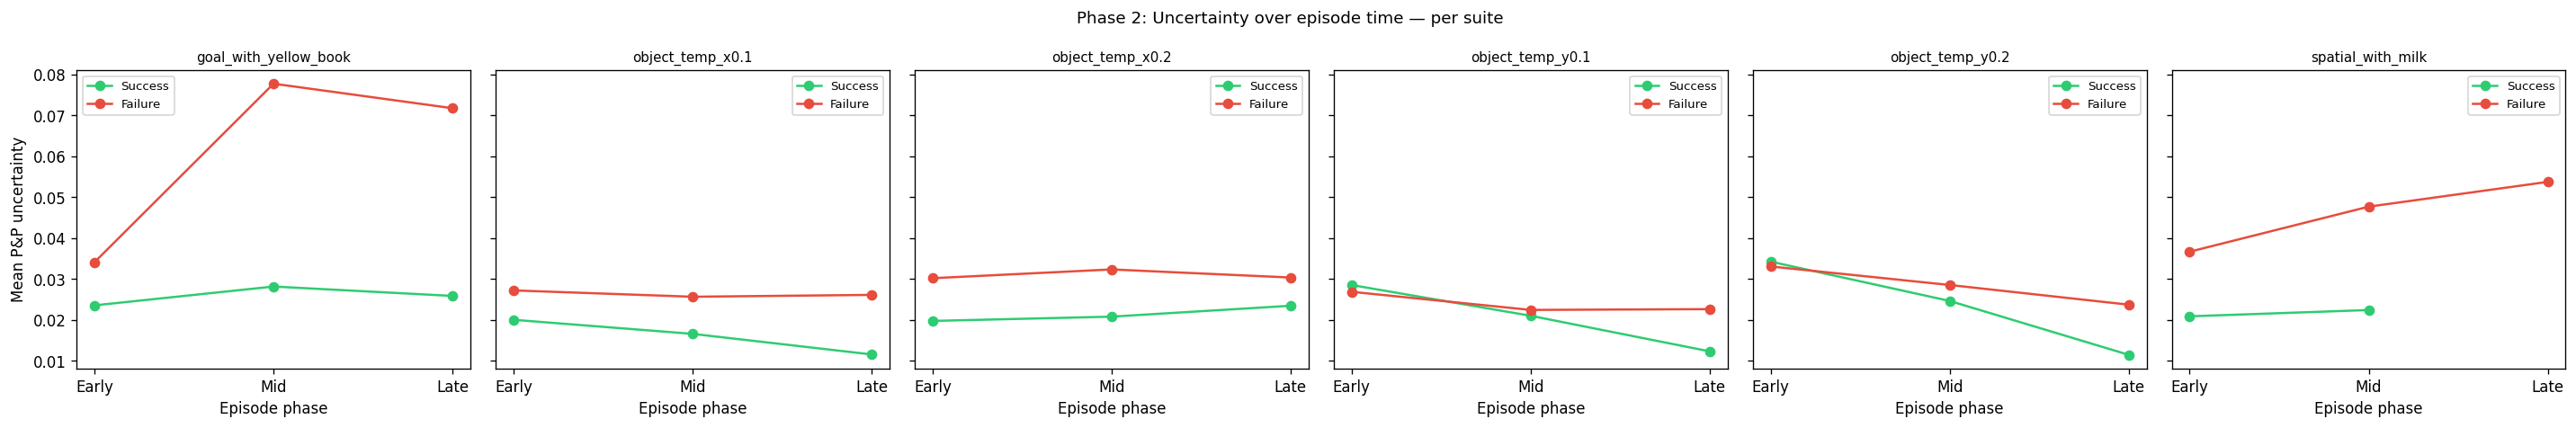

In [ ]:
if len(steps_p2) == 0:
    print('No Phase 2 data yet.')
else:
    steps_j = steps_p2.merge(
        phase2[['rollout_id','success','suite']], on='rollout_id', how='left')

    # Bin chunk_idx into early / mid / late thirds
    max_chunk = steps_j.groupby('rollout_id')['chunk_idx'].transform('max').clip(lower=0)
    steps_j['time_bin'] = pd.cut(
        steps_j['chunk_idx'] / (max_chunk + 1),
        bins=[0, 1/3, 2/3, 1.0001],
        labels=['Early', 'Mid', 'Late'],
        include_lowest=True
    )

    suites   = sorted(steps_j['suite'].dropna().unique())
    n_suites = len(suites)

    fig, axes = plt.subplots(1, n_suites, figsize=(4 * n_suites, 4), sharey=True)
    if n_suites == 1: axes = [axes]

    for ax, suite in zip(axes, suites):
        sub = steps_j[steps_j.suite == suite]
        by_bin = (sub.groupby(['time_bin','success'])
                  .agg(u_mean=('u_mean','mean'), u_std=('u_mean','std'))
                  .reset_index())
        bins = ['Early', 'Mid', 'Late']
        for outcome, label, color in [(1,'Success','#2ecc71'), (0,'Failure','#e74c3c')]:
            g = by_bin[by_bin.success == outcome]
            u_vals = [g[g.time_bin == b]['u_mean'].values[0]
                      if len(g[g.time_bin == b]) else np.nan for b in bins]
            ax.plot(range(len(bins)), u_vals, marker='o', color=color, label=label)
        ax.set_xticks(range(len(bins)))
        ax.set_xticklabels(bins)
        ax.set_xlabel('Episode phase')
        if ax is axes[0]: ax.set_ylabel('Mean P&P uncertainty')
        ax.set_title(suite.replace('libero_',''), fontsize=9)
        ax.legend(fontsize=8)

    fig.suptitle('Phase 2: Uncertainty over episode time — per suite', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/uncertainty_over_time.png', dpi=150)
    plt.show()

## A9. Per-Task P&P Lift — Before vs. After Refinement

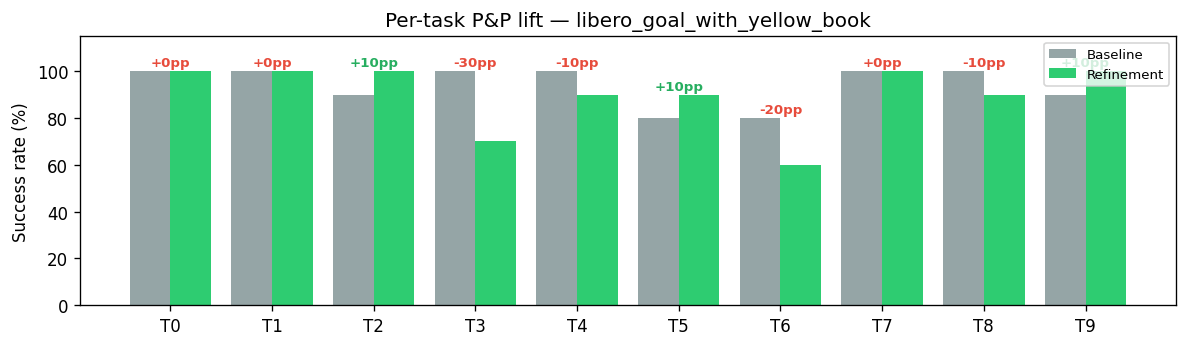

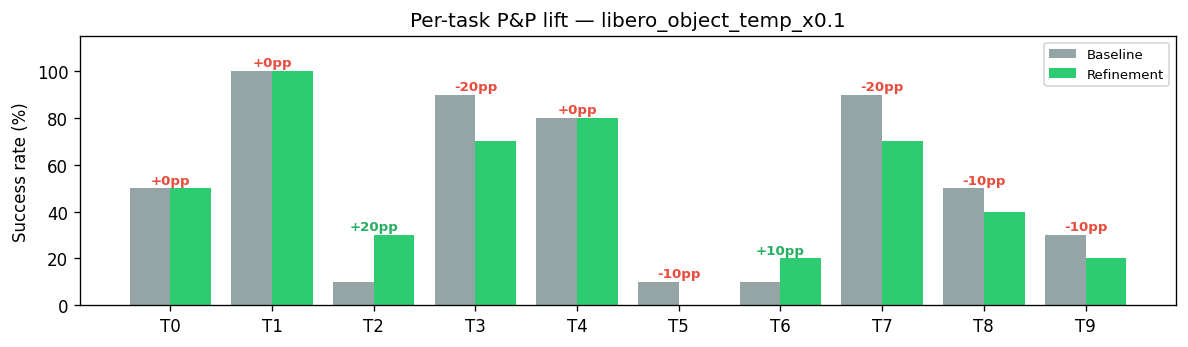

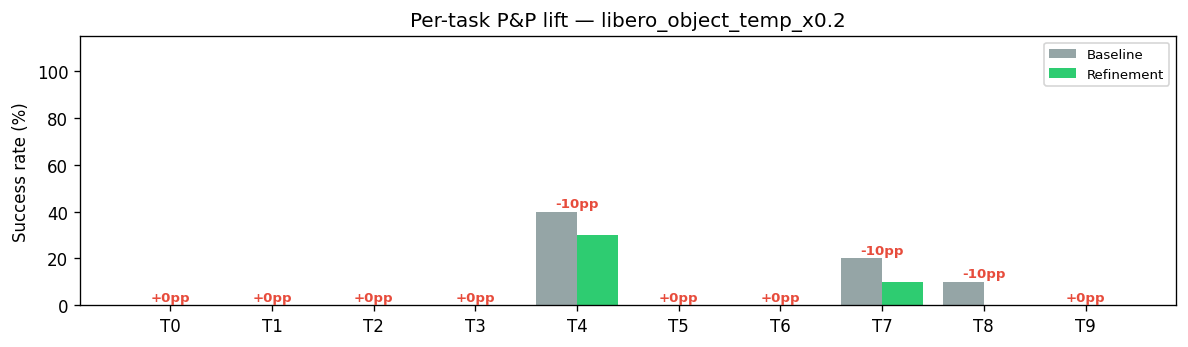

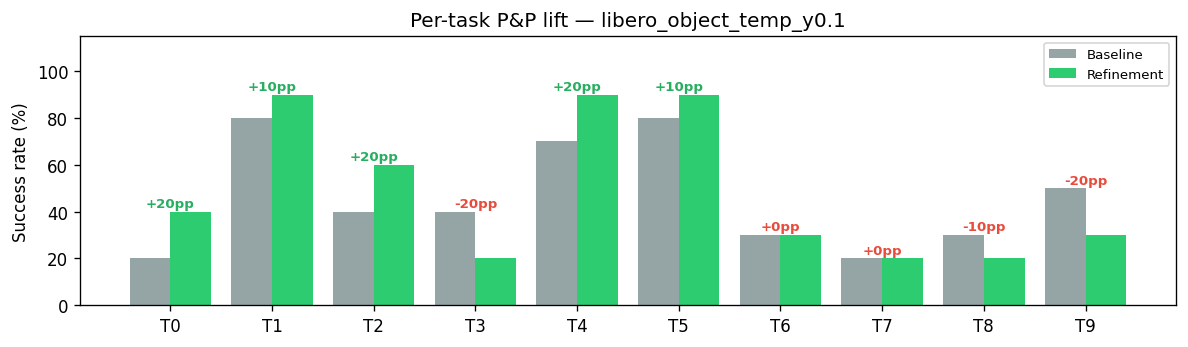

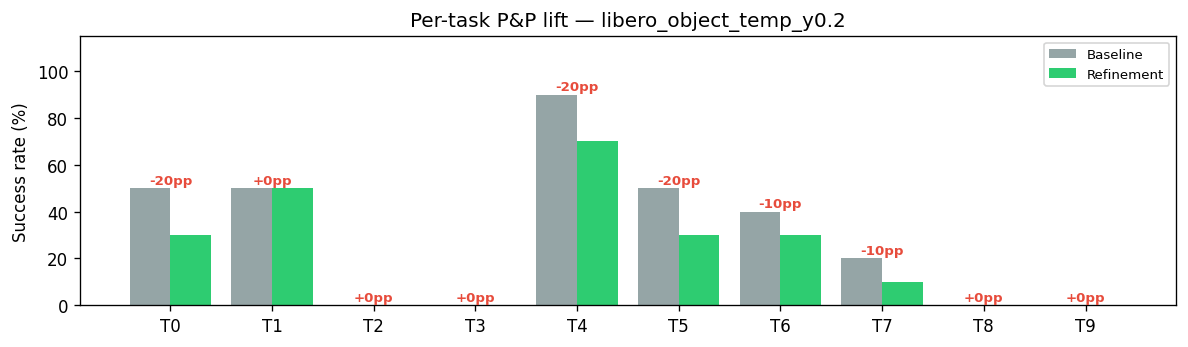

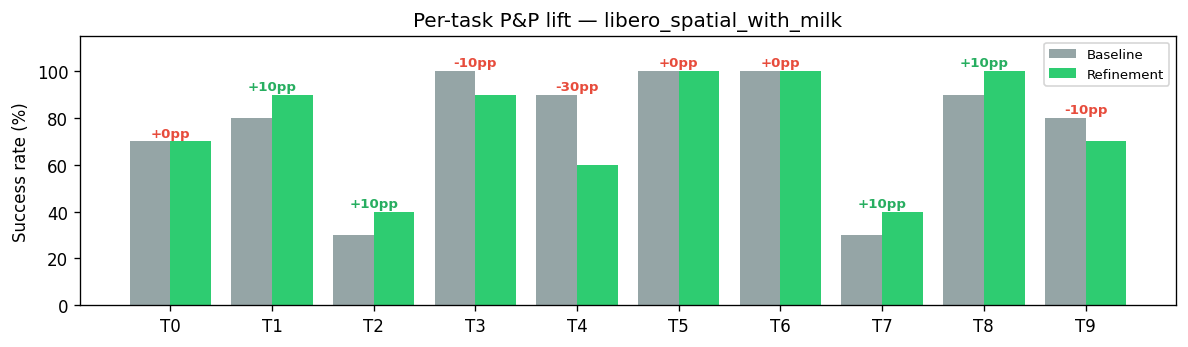


Top-5 biggest P&P improvements (failure → success):
                   suite  task_idx  sr_baseline  sr_pnp  lift
 libero_object_temp_y0.1         4          0.7     0.9   0.2
 libero_object_temp_y0.1         0          0.2     0.4   0.2
 libero_object_temp_x0.1         2          0.1     0.3   0.2
 libero_object_temp_y0.1         2          0.4     0.6   0.2
libero_spatial_with_milk         2          0.3     0.4   0.1

Top-5 biggest regressions (success → failure):
                       suite  task_idx  sr_baseline  sr_pnp  lift
libero_goal_with_yellow_book         3          1.0     0.7  -0.3
    libero_spatial_with_milk         4          0.9     0.6  -0.3
libero_goal_with_yellow_book         6          0.8     0.6  -0.2
     libero_object_temp_x0.1         3          0.9     0.7  -0.2
     libero_object_temp_x0.1         7          0.9     0.7  -0.2


In [ ]:
if len(phase3) == 0:
    print('No Phase 3 data yet.')
else:
    base_task = baseline.groupby(['suite','task_idx'])['success'].mean().reset_index()
    base_task.columns = ['suite','task_idx','sr_baseline']
    pnp_task  = phase3.groupby(['suite','task_idx'])['success'].mean().reset_index()
    pnp_task.columns  = ['suite','task_idx','sr_pnp']

    lift_df = base_task.merge(pnp_task, on=['suite','task_idx'], how='inner')
    lift_df['lift'] = lift_df['sr_pnp'] - lift_df['sr_baseline']

    suites = sorted(lift_df['suite'].unique())

    for suite in suites:
        g = lift_df[lift_df.suite == suite].sort_values('task_idx')
        fig, ax = plt.subplots(figsize=(10, 3))
        x  = np.arange(len(g))
        ax.bar(x - 0.2, g['sr_baseline'] * 100, width=0.4,
               label='Baseline', color='#95a5a6')
        ax.bar(x + 0.2, g['sr_pnp'] * 100, width=0.4,
               label='Refinement', color='#2ecc71')
        for xi, (_, row) in zip(x, g.iterrows()):
            lift = row['lift']
            color = '#27ae60' if lift > 0 else '#e74c3c'
            ax.annotate(f'{lift*100:+.0f}pp', xy=(xi, max(row['sr_baseline'], row['sr_pnp'])*100 + 2),
                        ha='center', fontsize=8, color=color, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'T{i}' for i in g['task_idx']])
        ax.set_ylabel('Success rate (%)')
        ax.set_ylim(0, 115)
        ax.set_title(f'Per-task P&P lift — {suite}')
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(f'{RESULTS_DIR}/pnp_lift_{suite}.png', dpi=150)
        plt.show()

    # Summary: biggest improvers and regressors
    print('\nTop-5 biggest P&P improvements (failure → success):')
    top = lift_df.nlargest(5, 'lift')[['suite','task_idx','sr_baseline','sr_pnp','lift']]
    print(top.to_string(index=False))
    print('\nTop-5 biggest regressions (success → failure):')
    bot = lift_df.nsmallest(5, 'lift')[['suite','task_idx','sr_baseline','sr_pnp','lift']]
    print(bot.to_string(index=False))

## A10. Cross-Suite Comparison — Position Perturbation vs. Distractor

Cross-suite summary:
                       suite       suite_type  sr_baseline  sr_pnp  lift      auc   u_mean
libero_goal_with_yellow_book       distractor         0.94    0.90 -0.04 0.939716 0.026554
     libero_object_temp_x0.1 position_perturb         0.52    0.48 -0.04 0.876202 0.022152
     libero_object_temp_x0.2 position_perturb         0.07    0.04 -0.03 0.846467 0.030065
     libero_object_temp_y0.1 position_perturb         0.46    0.49  0.03 0.513285 0.023885
     libero_object_temp_y0.2 position_perturb         0.30    0.22 -0.08 0.610476 0.028668
    libero_spatial_with_milk       distractor         0.77    0.76 -0.01 0.905783 0.026119


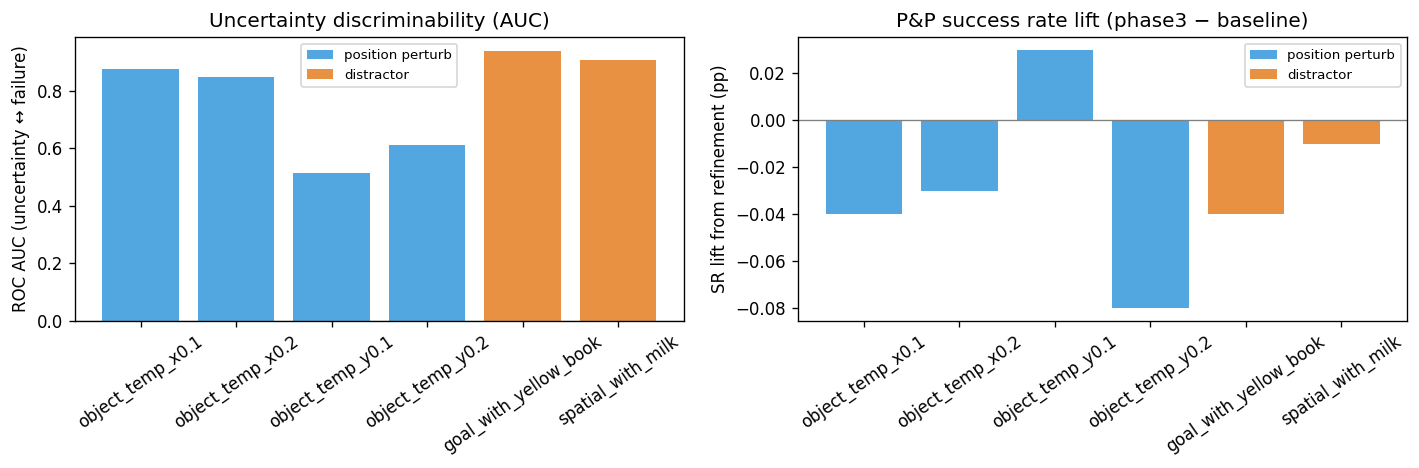


Means by suite type:
                  sr_baseline   lift    auc
suite_type                                 
distractor              0.855 -0.025  0.923
position_perturb        0.338 -0.030  0.712


In [ ]:
if len(phase2) == 0 or len(phase3) == 0:
    print('Need both Phase 2 and Phase 3 data for this comparison.')
else:
    summary_rows = []
    sub = phase2.dropna(subset=['u_mean_episode'])

    for suite in sorted(rollouts['suite'].unique()):
        base_sr = baseline[baseline.suite == suite]['success'].mean()
        pnp_sr  = phase3[phase3.suite == suite]['success'].mean()
        p2_sub  = sub[sub.suite == suite]

        # AUC
        roc_auc = float('nan')
        if p2_sub['success'].nunique() == 2:
            fpr, tpr, _ = roc_curve(1 - p2_sub['success'], p2_sub['u_mean_episode'])
            roc_auc = auc(fpr, tpr)

        summary_rows.append({
            'suite':       suite,
            'suite_type':  'position_perturb' if 'temp_' in suite else 'distractor',
            'sr_baseline': base_sr,
            'sr_pnp':      pnp_sr,
            'lift':        pnp_sr - base_sr if not np.isnan(pnp_sr) else np.nan,
            'auc':         roc_auc,
            'u_mean':      p2_sub['u_mean_episode'].mean(),
        })

    summary = pd.DataFrame(summary_rows)
    print('Cross-suite summary:')
    print(summary.to_string(index=False))

    # Grouped comparison chart
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, (col, ylabel, title) in zip(axes, [
        ('auc',  'ROC AUC (uncertainty ↔ failure)', 'Uncertainty discriminability (AUC)'),
        ('lift', 'SR lift from refinement (pp)',     'P&P success rate lift (phase3 − baseline)'),
    ]):
        for stype, color in [('position_perturb','#3498db'), ('distractor','#e67e22')]:
            g = summary[summary.suite_type == stype].dropna(subset=[col])
            if g.empty: continue
            ax.bar(g['suite'].str.replace('libero_',''), g[col],
                   color=color, label=stype.replace('_',' '), alpha=0.85)
        ax.axhline(0, color='gray', lw=0.8)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.tick_params(axis='x', rotation=35)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_suite_comparison.png', dpi=150)
    plt.show()

    # Group-level means
    print('\nMeans by suite type:')
    print(summary.groupby('suite_type')[['sr_baseline','lift','auc']].mean().round(3).to_string())

## A11. Pairing Coverage Diagnostics

In [ ]:
print('Pairing coverage diagnostics')
print('=' * 55)

for label, df in [('Phase 2 (uncertainty)', phase2), ('Phase 3 (refinement)', phase3)]:
    if len(df) == 0:
        print(f'{label}: no data')
        continue

    # Pair on (suite, task_idx, episode_idx, init_state_hash)
    keys = ['suite', 'task_idx', 'episode_idx', 'init_state_hash']
    base_keys = set(map(tuple, baseline[keys].values.tolist()))
    pnp_keys  = set(map(tuple, df[keys].values.tolist()))

    paired_count = len(base_keys & pnp_keys)
    coverage     = paired_count / len(base_keys) if base_keys else 0
    print(f'\n{label}')
    print(f'  Baseline episodes:       {len(baseline)}')
    print(f'  {label[:20]} episodes: {len(df)}')
    print(f'  Paired (hash match):     {paired_count}')
    print(f'  Coverage:                {coverage:.1%}')

    # Per-suite breakdown
    for suite in sorted(rollouts['suite'].unique()):
        b = len(baseline[baseline.suite == suite])
        p = len(df[df.suite == suite])
        bk = set(map(tuple, baseline[baseline.suite == suite][keys].values.tolist()))
        pk = set(map(tuple, df[df.suite == suite][keys].values.tolist()))
        paired = len(bk & pk)
        print(f'    {suite:<42} base={b}  pnp={p}  paired={paired}')

Pairing coverage diagnostics

Phase 2 (uncertainty)
  Baseline episodes:       600
  Phase 2 (uncertainty episodes: 600
  Paired (hash match):     600
  Coverage:                100.0%
    libero_goal_with_yellow_book               base=100  pnp=100  paired=100
    libero_object_temp_x0.1                    base=100  pnp=100  paired=100
    libero_object_temp_x0.2                    base=100  pnp=100  paired=100
    libero_object_temp_y0.1                    base=100  pnp=100  paired=100
    libero_object_temp_y0.2                    base=100  pnp=100  paired=100
    libero_spatial_with_milk                   base=100  pnp=100  paired=100

Phase 3 (refinement)
  Baseline episodes:       600
  Phase 3 (refinement) episodes: 600
  Paired (hash match):     600
  Coverage:                100.0%
    libero_goal_with_yellow_book               base=100  pnp=100  paired=100
    libero_object_temp_x0.1                    base=100  pnp=100  paired=100
    libero_object_temp_x0.2                 